# Antennal lobe model: reward-gated lateral inhibitory plasticity

**Core question**

Can an antennal-lobe-only network explain why, after appetitive training of odor **A+**, an **A+B mixture** becomes represented more like **A** than **B**?

The model tests this idea with four conditions:

1. `static`: no plasticity.
2. `LN→PN surround`: reward-gated potentiation of lateral inhibition from A-driven LNs onto non-A PN targets.
3. `LN→LN disinhibition`: reward-gated potentiation from A-driven LNs onto competitor LNs.
4. `combined`: both mechanisms together.

The key prediction is:

\[
d(\mathrm{Mix},B) - d(\mathrm{Mix},A) > 0
\]

meaning that the mixture is closer to **A** than to **B** in PN population space.

## 0. Environment notes

The rate model does **not** require Brian2. It needs `numpy`, `pandas`, `matplotlib`, and optionally `scikit-learn` for PCA.

The final optional section contains a minimal Brian2 spiking sanity-check, switched off by default.

In [ ]:
# If needed, run once:
# !pip install numpy pandas matplotlib scikit-learn nbformat
# Optional:
# !pip install brian2

## 1. Imports, output folder, and global configuration

In [1]:
from pathlib import Path
from dataclasses import dataclass
from copy import deepcopy
import re
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

try:
    from sklearn.decomposition import PCA
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False

warnings.filterwarnings("ignore", category=RuntimeWarning)

OUTPUT_DIR = Path("results_AL_local_plasticity")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAVE_FIGURES = True
SAVE_SVG = False  # Set True if you also want vector SVG files; PNG saving is much faster.
SAVE_TABLES = True
SHOW_FIGURES = True

def safe_name(text):
    """Filesystem-safe figure/table name."""
    text = str(text).replace("→", "to").replace("+", "plus")
    text = re.sub(r"[^A-Za-z0-9_.-]+", "_", text)
    return text.strip("_")

def savefig(fig, name, dpi=300):
    """Save every figure as PNG and SVG, then optionally show it."""
    if SAVE_FIGURES:
        stem = safe_name(name)
        fig.savefig(OUTPUT_DIR / f"{stem}.png", dpi=dpi, bbox_inches="tight")
        if SAVE_SVG:
            fig.savefig(OUTPUT_DIR / f"{stem}.svg", bbox_inches="tight")
    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)

def save_table(df, name):
    if SAVE_TABLES:
        df.to_csv(OUTPUT_DIR / f"{safe_name(name)}.csv", index=False)

def trapz_compat(y, dx=1.0, axis=0):
    """
    NumPy 2.x removed np.trapz in some environments.
    Use np.trapezoid if available, otherwise fall back to np.trapz.
    """
    if hasattr(np, "trapezoid"):
        return np.trapezoid(y, dx=dx, axis=axis)
    return np.trapz(y, dx=dx, axis=axis)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 2. Model parameters

In [2]:
@dataclass
class ModelParams:
    # Network size
    n_glom: int = 20
    n_trials: int = 5

    # Odor input thresholds
    active_thr: float = 0.12
    strong_thr: float = 0.60

    # Rate model parameters
    base_pn: float = 2.0
    base_ln: float = 4.0
    gain_pn: float = 34.0
    gain_ln: float = 38.0
    g_lnpn: float = 1.45
    g_lnln: float = 0.75
    rate_max: float = 35.0
    n_rate_iterations: int = 40

    # Initial connectivity
    p_lnpn: float = 0.42
    p_lnln: float = 0.30
    init_w_lnpn_scale: float = 0.075
    init_w_lnln_scale: float = 0.045

    # Plasticity
    eta_lnpn: float = 0.040
    eta_lnln: float = 0.055
    w_lnpn_max: float = 0.42
    w_lnln_max: float = 0.28
    reward: float = 1.0

    # Optional small decay, left at zero for clean interpretation
    lnpn_decay: float = 0.0
    lnln_decay: float = 0.0

    # Temporal traces
    dt_ms: float = 5.0
    t_pre_ms: float = 500.0
    t_odor_ms: float = 2000.0
    t_post_ms: float = 500.0
    tau_on_ms: float = 55.0
    tau_off_ms: float = 90.0
    trace_noise_sd: float = 0.10

P = ModelParams()

CONDITIONS = [
    "static",
    "LN→PN surround",
    "LN→LN disinhibition",
    "combined",
]

ODORS = ["A+", "B", "Mix"]
POPULATIONS = ["PN", "LN"]

CATEGORY_ORDER = ["A_only", "B_only", "overlap", "weak_candidate", "mix_revealed_input", "background"]
CATEGORY_COLORS = {
    "A_only": "tab:blue",
    "B_only": "tab:orange",
    "overlap": "tab:green",
    "weak_candidate": "tab:purple",
    "mix_revealed_input": "tab:red",
    "background": "tab:gray",
}

## 3. Odor input construction

The input is controlled so that categories are not accidentally empty.

- `A_only`: strong in A, weak in B.
- `B_only`: strong in B, weak in A.
- `overlap`: active in both A and B.
- `weak_candidate`: weak/subthreshold in components, can become slightly more visible in the mixture.
- `background`: weak in all cases.

In [3]:
def normalize01(x, eps=1e-12):
    x = np.asarray(x, dtype=float)
    return (x - np.nanmin(x)) / (np.nanmax(x) - np.nanmin(x) + eps)

def relu_cap(x, cap):
    return np.clip(x, 0.0, cap)

def build_odor_inputs(seed=0, p=P):
    """
    Build structured but seed-dependent odor inputs.
    Returns:
        odors: dict with A+, B, Mix arrays.
        categories: array of glomerular category labels.
        groups: dict of category -> glomerulus indices.
    """
    rng = np.random.default_rng(seed)
    n = p.n_glom
    perm = rng.permutation(n)

    groups = {
        "A_only": perm[:5],
        "B_only": perm[5:8],
        "overlap": perm[8:12],
        "weak_candidate": perm[12:16],
        "background": perm[16:],
    }

    categories = np.empty(n, dtype=object)
    A = np.zeros(n)
    B = np.zeros(n)

    for cat, inds in groups.items():
        categories[inds] = cat
        if cat == "A_only":
            A[inds] = rng.uniform(0.72, 0.95, len(inds))
            B[inds] = rng.uniform(0.02, 0.07, len(inds))
        elif cat == "B_only":
            A[inds] = rng.uniform(0.02, 0.07, len(inds))
            B[inds] = rng.uniform(0.72, 0.95, len(inds))
        elif cat == "overlap":
            A[inds] = rng.uniform(0.55, 0.82, len(inds))
            B[inds] = rng.uniform(0.45, 0.75, len(inds))
        elif cat == "weak_candidate":
            A[inds] = rng.uniform(0.06, 0.14, len(inds))
            B[inds] = rng.uniform(0.06, 0.14, len(inds))
        elif cat == "background":
            A[inds] = rng.uniform(0.01, 0.08, len(inds))
            B[inds] = rng.uniform(0.01, 0.08, len(inds))

    # Mixture input: mostly strongest-component rule, with mild nonlinearity/noise.
    max_ab = np.maximum(A, B)
    summation = A + B
    Mix = 0.92 * max_ab + 0.08 * summation + rng.normal(0.0, 0.025, n)

    # Weak glomeruli can become slightly more visible in mixture.
    wc = groups["weak_candidate"]
    Mix[wc] += rng.uniform(0.04, 0.10, len(wc))
    Mix = np.clip(Mix, 0.0, 0.98)

    # Re-label weak candidates if they are actually above active threshold in the mixture.
    for g in wc:
        if Mix[g] >= p.active_thr and A[g] < p.active_thr and B[g] < p.active_thr:
            categories[g] = "mix_revealed_input"

    odors = {"A+": A, "B": B, "Mix": Mix}
    return odors, categories, groups

def order_glomeruli_for_display(odors):
    """
    Order glomeruli for readable heatmaps: first A/B specificity, then overall strength.
    """
    A, B, M = odors["A+"], odors["B"], odors["Mix"]
    specificity = A - B
    strength = np.maximum.reduce([A, B, M])
    return np.lexsort((-strength, specificity))

## 4. Connectivity and rate equations

In [4]:
def build_network(seed=0, p=P):
    """
    Build sparse LN→PN and LN→LN inhibitory connectivity.
    Rows are presynaptic LNs. Columns are target PNs or target LNs.
    """
    rng = np.random.default_rng(seed + 10000)
    n = p.n_glom

    mask_lnpn = rng.random((n, n)) < p.p_lnpn
    mask_lnln = rng.random((n, n)) < p.p_lnln
    np.fill_diagonal(mask_lnln, False)

    W_lnpn = mask_lnpn * rng.gamma(shape=2.0, scale=p.init_w_lnpn_scale / 2.0, size=(n, n))
    W_lnln = mask_lnln * rng.gamma(shape=2.0, scale=p.init_w_lnln_scale / 2.0, size=(n, n))

    return {
        "W_LNPN0": W_lnpn,
        "W_LNLN0": W_lnln,
        "mask_LNPN": mask_lnpn,
        "mask_LNLN": mask_lnln,
    }

def solve_rates(odor_drive, W_lnpn, W_lnln, p=P):
    """
    Fixed-point rate model.

    LN receives ORN drive and LN→LN inhibition.
    PN receives ORN drive and LN→PN inhibition.
    """
    odor_drive = np.asarray(odor_drive, dtype=float)

    LN = relu_cap(p.base_ln + p.gain_ln * odor_drive, p.rate_max)

    for _ in range(p.n_rate_iterations):
        inhib_ln = LN @ W_lnln
        new_LN = relu_cap(p.base_ln + p.gain_ln * odor_drive - p.g_lnln * inhib_ln, p.rate_max)
        LN = 0.75 * LN + 0.25 * new_LN

    inhib_to_PN = LN @ W_lnpn
    PN = relu_cap(p.base_pn + p.gain_pn * odor_drive - p.g_lnpn * inhib_to_PN, p.rate_max)

    return PN, LN, inhib_to_PN

def evaluate_odors(odors, W_lnpn, W_lnln, p=P):
    tests = {}
    for odor_name, odor_drive in odors.items():
        PN, LN, inhib_to_PN = solve_rates(odor_drive, W_lnpn, W_lnln, p)
        tests[odor_name] = {
            "PN": PN,
            "LN": LN,
            "inhib_to_PN": inhib_to_PN,
        }
    return tests

## 5. Local reward-gated plasticity rules

Two plasticity mechanisms are implemented.

### 5.1 LN→PN surround potentiation

A-driven LNs potentiate inhibition onto targets weakly driven by A.

\[
\Delta W_{\mathrm{LN}\to\mathrm{PN}} \propto
R \cdot \mathrm{LN}_{pre}^{A} \cdot \mathrm{target}_{nonA}
\]

### 5.2 LN→LN directed disinhibition

A-driven LNs potentiate inhibition onto competitor LNs. Competitor LNs are identified locally as LNs whose outgoing weights inhibit A-active PN targets.

\[
\Delta W_{\mathrm{LN}\to\mathrm{LN}} \propto
R \cdot \mathrm{LN}_{pre}^{A} \cdot \mathrm{competitorLN}
\]

This is the key local mechanism that can disinhibit A-like PN channels during the mixture.

In [5]:
def local_plasticity_update(
    W_lnpn,
    W_lnln,
    mask_lnpn,
    mask_lnln,
    odors,
    p=P,
    allow_lnpn=True,
    allow_lnln=True,
):
    """
    Reward-gated local inhibitory plasticity during A+ training.

    Important:
    - No MB/LH layer is used.
    - Reward gates plasticity but does not define a downstream value readout.
    - The factors are computed from local AL variables: odor drive, current LN activity,
      and current inhibitory outgoing connectivity.
    """
    A = odors["A+"]

    PN_A, LN_A, _ = solve_rates(A, W_lnpn, W_lnln, p)

    # Presynaptic eligibility: A-driven LN activity.
    pre_factor = normalize01(LN_A) * (A > p.active_thr)

    # LN→PN target factor: heterosynaptic surround/inactive-target potentiation.
    target_surround = (1.0 - normalize01(A)) ** 1.25
    target_surround[A > p.strong_thr] *= 0.05  # spare strongly A-driven channels
    target_surround = normalize01(target_surround)

    # LN→LN competitor factor:
    # target LNs that currently inhibit A-active PN targets are competitor LNs.
    A_target_mask = A > p.active_thr
    competitor_factor = W_lnpn[:, A_target_mask].sum(axis=1)
    competitor_factor = normalize01(competitor_factor) * (1.0 - normalize01(A)) ** 0.70
    competitor_factor = normalize01(competitor_factor)

    dW_lnpn = np.zeros_like(W_lnpn)
    dW_lnln = np.zeros_like(W_lnln)

    if allow_lnpn:
        dW_lnpn = (
            p.reward
            * p.eta_lnpn
            * (pre_factor[:, None] * target_surround[None, :])
            * mask_lnpn
        )
        W_lnpn = np.clip((1.0 - p.lnpn_decay) * W_lnpn + dW_lnpn, 0.0, p.w_lnpn_max)

    if allow_lnln:
        dW_lnln = (
            p.reward
            * p.eta_lnln
            * (pre_factor[:, None] * competitor_factor[None, :])
            * mask_lnln
        )
        np.fill_diagonal(dW_lnln, 0.0)
        W_lnln = np.clip((1.0 - p.lnln_decay) * W_lnln + dW_lnln, 0.0, p.w_lnln_max)

    diag = {
        "PN_A": PN_A,
        "LN_A": LN_A,
        "pre_factor": pre_factor,
        "target_surround": target_surround,
        "competitor_factor": competitor_factor,
    }

    return W_lnpn, W_lnln, dW_lnpn, dW_lnln, diag

## 6. Simulation wrapper

In [6]:
def condition_flags(condition):
    if condition == "static":
        return False, False
    if condition == "LN→PN surround":
        return True, False
    if condition == "LN→LN disinhibition":
        return False, True
    if condition == "combined":
        return True, True
    raise ValueError(f"Unknown condition: {condition}")

def run_condition(seed=0, condition="combined", p=P):
    odors, categories, groups = build_odor_inputs(seed, p)
    net = build_network(seed, p)

    W_lnpn = net["W_LNPN0"].copy()
    W_lnln = net["W_LNLN0"].copy()

    result = {
        "seed": seed,
        "condition": condition,
        "odors": odors,
        "categories": categories,
        "groups": groups,
        "net": net,
        "W_LNPN_history": [W_lnpn.copy()],
        "W_LNLN_history": [W_lnln.copy()],
        "dW_LNPN_history": [],
        "dW_LNLN_history": [],
        "diag_history": [],
    }

    result["pre"] = evaluate_odors(odors, W_lnpn, W_lnln, p)

    allow_lnpn, allow_lnln = condition_flags(condition)

    for trial in range(1, p.n_trials + 1):
        W_lnpn, W_lnln, dW_lnpn, dW_lnln, diag = local_plasticity_update(
            W_lnpn=W_lnpn,
            W_lnln=W_lnln,
            mask_lnpn=net["mask_LNPN"],
            mask_lnln=net["mask_LNLN"],
            odors=odors,
            p=p,
            allow_lnpn=allow_lnpn,
            allow_lnln=allow_lnln,
        )
        result["W_LNPN_history"].append(W_lnpn.copy())
        result["W_LNLN_history"].append(W_lnln.copy())
        result["dW_LNPN_history"].append(dW_lnpn.copy())
        result["dW_LNLN_history"].append(dW_lnln.copy())
        result["diag_history"].append(diag)

    result["post"] = evaluate_odors(odors, W_lnpn, W_lnln, p)

    return result

def run_all_conditions(seed=0, p=P):
    return {cond: run_condition(seed=seed, condition=cond, p=p) for cond in CONDITIONS}

## 7. Distances, A-bias, and summary metrics

In [7]:
def zscore_vector(v):
    v = np.asarray(v, dtype=float)
    return (v - np.nanmean(v)) / (np.nanstd(v) + 1e-12)

def distance(v1, v2, metric="euclidean_z"):
    v1 = np.asarray(v1, dtype=float)
    v2 = np.asarray(v2, dtype=float)

    if metric == "euclidean":
        return float(np.linalg.norm(v1 - v2))

    if metric == "euclidean_z":
        return float(np.linalg.norm(zscore_vector(v1) - zscore_vector(v2)))

    if metric == "cosine_distance":
        denom = np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-12
        return float(1.0 - np.dot(v1, v2) / denom)

    raise ValueError(f"Unknown metric: {metric}")

def collect_distance_metrics(result, state="post", population="PN"):
    reps = {odor: result[state][odor][population] for odor in ODORS}

    rows = []
    for metric in ["euclidean", "euclidean_z", "cosine_distance"]:
        for pair_name, a, b in [
            ("A-B", "A+", "B"),
            ("A-Mix", "A+", "Mix"),
            ("B-Mix", "B", "Mix"),
        ]:
            rows.append({
                "seed": result["seed"],
                "condition": result["condition"],
                "state": state,
                "population": population,
                "metric": metric,
                "pair": pair_name,
                "value": distance(reps[a], reps[b], metric),
            })

        d_a_mix = distance(reps["A+"], reps["Mix"], metric)
        d_b_mix = distance(reps["B"], reps["Mix"], metric)
        rows.append({
            "seed": result["seed"],
            "condition": result["condition"],
            "state": state,
            "population": population,
            "metric": metric,
            "pair": "Mix A-bias",
            "value": d_b_mix - d_a_mix,
        })

    return rows

def collect_all_distance_metrics(results):
    rows = []
    for result in results.values():
        for state in ["pre", "post"]:
            for population in POPULATIONS:
                rows.extend(collect_distance_metrics(result, state=state, population=population))
    df = pd.DataFrame(rows)
    save_table(df, "single_seed_distance_metrics")
    return df

def get_response(result, odor, population="PN", state="post"):
    return result[state][odor][population]

def mix_a_bias(result, population="PN", state="post", metric="euclidean_z"):
    A = get_response(result, "A+", population, state)
    B = get_response(result, "B", population, state)
    M = get_response(result, "Mix", population, state)
    return distance(M, B, metric) - distance(M, A, metric)

## 8. Run one example seed

In [8]:
SEED = 7
results = run_all_conditions(seed=SEED, p=P)
distance_df = collect_all_distance_metrics(results)

print(f"Finished one-seed simulation. Results saved in: {OUTPUT_DIR.resolve()}")
display(distance_df.head(12))

Finished one-seed simulation. Results saved in: C:\Users\agust\OneDrive\Desktop notebook casa\results_AL_local_plasticity


,seed,condition,state,population,metric,pair,value
0,7,static,pre,PN,euclidean,A-B,61.580165
1,7,static,pre,PN,euclidean,A-Mix,30.964908
2,7,static,pre,PN,euclidean,B-Mix,41.364885
3,7,static,pre,PN,euclidean,Mix A-bias,10.399977
4,7,static,pre,PN,euclidean_z,A-B,6.940826
5,7,static,pre,PN,euclidean_z,A-Mix,3.523034
6,7,static,pre,PN,euclidean_z,B-Mix,4.962274
7,7,static,pre,PN,euclidean_z,Mix A-bias,1.439240
8,7,static,pre,PN,cosine_distance,A-B,0.810276
9,7,static,pre,PN,cosine_distance,A-Mix,0.189654


## 9. Input dashboard

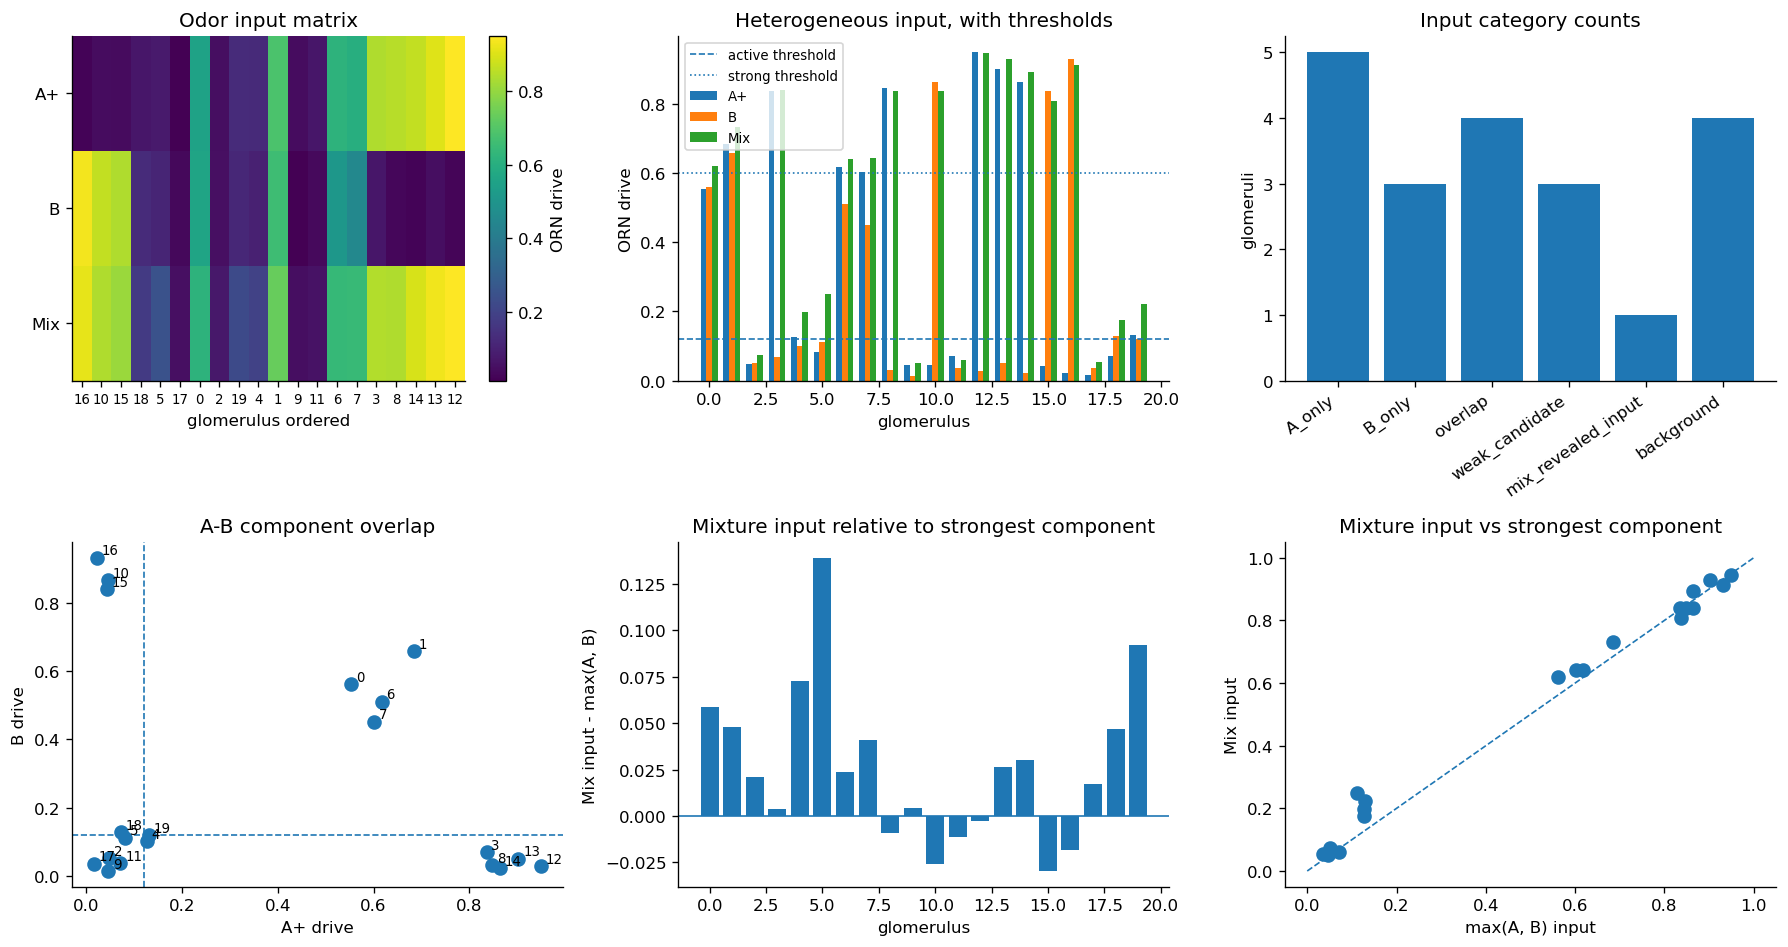

In [9]:
def plot_input_dashboard(result, p=P):
    odors = result["odors"]
    categories = result["categories"]
    order = order_glomeruli_for_display(odors)

    A = odors["A+"]
    B = odors["B"]
    M = odors["Mix"]

    input_matrix = np.vstack([A, B, M])

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    ax = axes[0, 0]
    im = ax.imshow(input_matrix[:, order], aspect="auto")
    ax.set_title("Odor input matrix")
    ax.set_yticks(range(3))
    ax.set_yticklabels(["A+", "B", "Mix"])
    ax.set_xticks(range(p.n_glom))
    ax.set_xticklabels(order, fontsize=8)
    ax.set_xlabel("glomerulus ordered")
    fig.colorbar(im, ax=ax, label="ORN drive")

    ax = axes[0, 1]
    x = np.arange(p.n_glom)
    width = 0.25
    ax.bar(x - width, A, width, label="A+")
    ax.bar(x, B, width, label="B")
    ax.bar(x + width, M, width, label="Mix")
    ax.axhline(p.active_thr, linestyle="--", linewidth=1, label="active threshold")
    ax.axhline(p.strong_thr, linestyle=":", linewidth=1, label="strong threshold")
    ax.set_title("Heterogeneous input, with thresholds")
    ax.set_xlabel("glomerulus")
    ax.set_ylabel("ORN drive")
    ax.legend(fontsize=8)

    ax = axes[0, 2]
    counts = pd.Series(categories).value_counts().reindex(CATEGORY_ORDER, fill_value=0)
    ax.bar(range(len(counts)), counts.values)
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=35, ha="right")
    ax.set_ylabel("glomeruli")
    ax.set_title("Input category counts")

    ax = axes[1, 0]
    ax.scatter(A, B, s=60)
    for g in range(p.n_glom):
        ax.text(A[g] + 0.01, B[g] + 0.01, str(g), fontsize=8)
    ax.axvline(p.active_thr, linestyle="--", linewidth=1)
    ax.axhline(p.active_thr, linestyle="--", linewidth=1)
    ax.set_xlabel("A+ drive")
    ax.set_ylabel("B drive")
    ax.set_title("A-B component overlap")

    ax = axes[1, 1]
    rel = M - np.maximum(A, B)
    ax.bar(np.arange(p.n_glom), rel)
    ax.axhline(0, linewidth=1)
    ax.set_xlabel("glomerulus")
    ax.set_ylabel("Mix input - max(A, B)")
    ax.set_title("Mixture input relative to strongest component")

    ax = axes[1, 2]
    ax.scatter(np.maximum(A, B), M, s=60)
    xx = np.linspace(0, 1, 100)
    ax.plot(xx, xx, linestyle="--", linewidth=1)
    ax.set_xlabel("max(A, B) input")
    ax.set_ylabel("Mix input")
    ax.set_title("Mixture input vs strongest component")

    fig.tight_layout()
    savefig(fig, "01_input_dashboard")

plot_input_dashboard(results["static"])

## 10. Circuit schematic and connectivity visualization

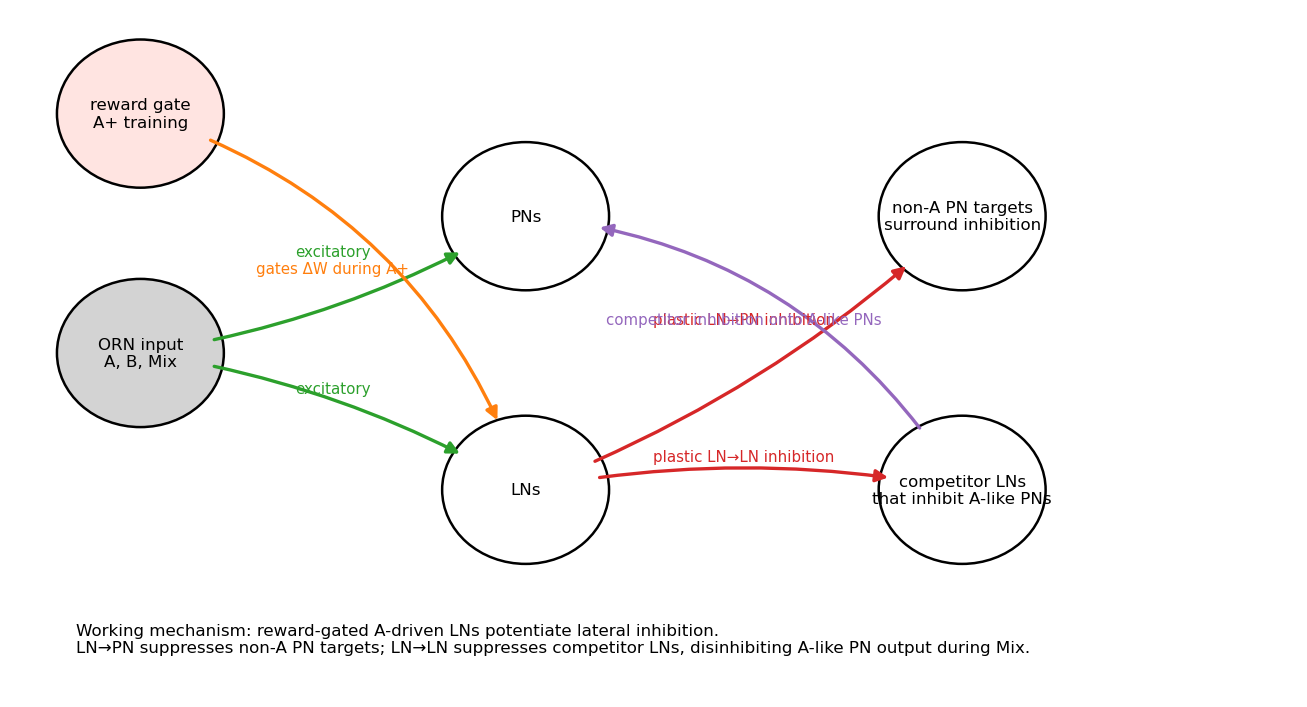

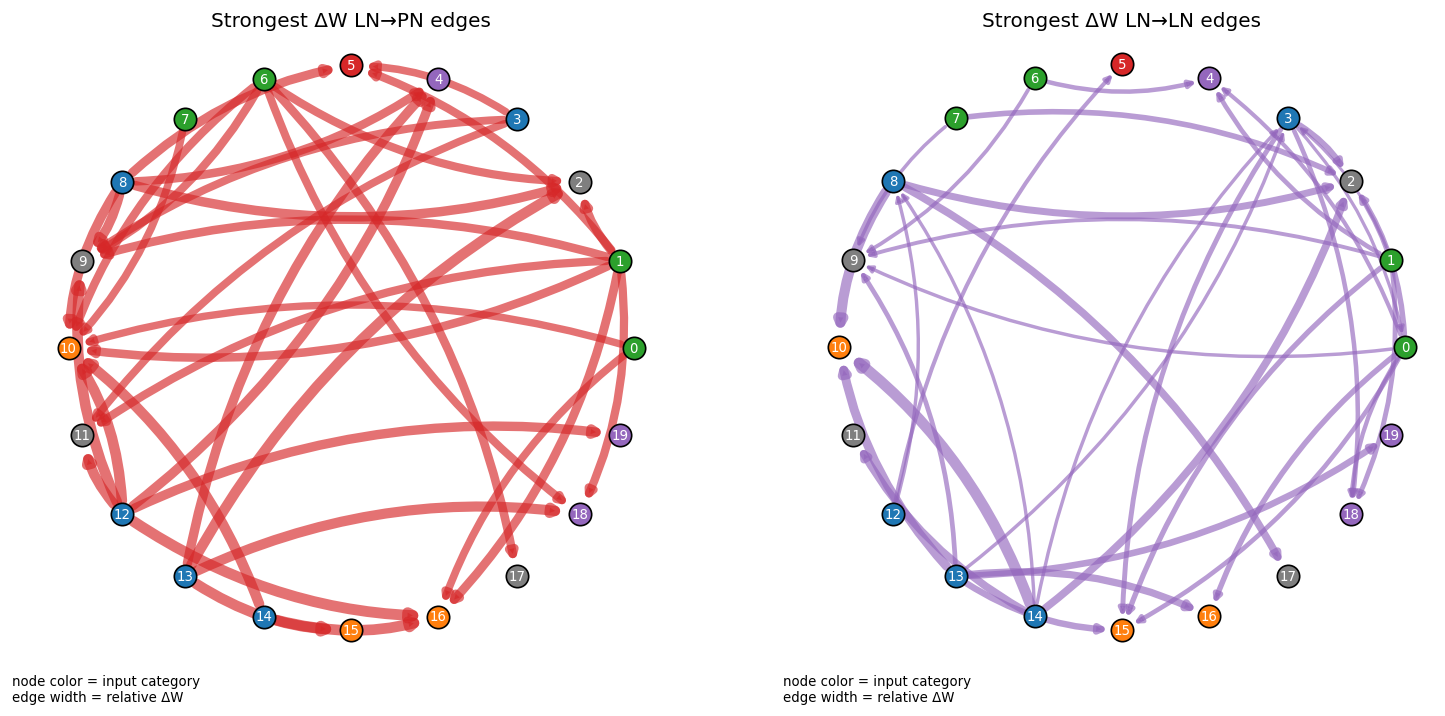

In [10]:
from matplotlib.patches import FancyArrowPatch, Circle

def draw_circuit_schematic():
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 6)
    ax.axis("off")

    pos = {
        "ORN": (1.0, 3.0),
        "PN": (4.0, 4.2),
        "LN": (4.0, 1.8),
        "reward": (1.0, 5.1),
        "PN targets": (7.4, 4.2),
        "competitor LNs": (7.4, 1.8),
    }

    node_specs = {
        "ORN": ("ORN input\nA, B, Mix", "lightgray"),
        "PN": ("PNs", "white"),
        "LN": ("LNs", "white"),
        "reward": ("reward gate\nA+ training", "mistyrose"),
        "PN targets": ("non-A PN targets\nsurround inhibition", "white"),
        "competitor LNs": ("competitor LNs\nthat inhibit A-like PNs", "white"),
    }

    for key, (label, color) in node_specs.items():
        x, y = pos[key]
        circ = Circle((x, y), radius=0.65, facecolor=color, edgecolor="black", linewidth=1.5)
        ax.add_patch(circ)
        ax.text(x, y, label, ha="center", va="center", fontsize=10)

    def arrow(a, b, text="", color="black", style="-|>", rad=0.0, lw=2):
        pa, pb = pos[a], pos[b]
        arr = FancyArrowPatch(
            pa, pb, arrowstyle=style, mutation_scale=15,
            linewidth=lw, color=color, connectionstyle=f"arc3,rad={rad}",
            shrinkA=45, shrinkB=45
        )
        ax.add_patch(arr)
        if text:
            mx, my = (pa[0]+pb[0])/2, (pa[1]+pb[1])/2
            ax.text(mx, my + 0.25, text, ha="center", fontsize=9, color=color)

    arrow("ORN", "PN", "excitatory", color="tab:green", rad=0.10)
    arrow("ORN", "LN", "excitatory", color="tab:green", rad=-0.10)
    arrow("LN", "PN targets", "plastic LN→PN inhibition", color="tab:red", rad=0.10)
    arrow("LN", "competitor LNs", "plastic LN→LN inhibition", color="tab:red", rad=-0.10)
    arrow("competitor LNs", "PN", "competitor inhibition onto A-like PNs", color="tab:purple", rad=0.25)
    arrow("reward", "LN", "gates ΔW during A+", color="tab:orange", rad=-0.25)

    ax.text(
        0.5, 0.35,
        "Working mechanism: reward-gated A-driven LNs potentiate lateral inhibition.\n"
        "LN→PN suppresses non-A PN targets; LN→LN suppresses competitor LNs, disinhibiting A-like PN output during Mix.",
        fontsize=10, ha="left", va="bottom"
    )

    fig.tight_layout()
    savefig(fig, "02_circuit_schematic")

def circle_positions(n):
    theta = np.linspace(0, 2*np.pi, n, endpoint=False)
    return np.c_[np.cos(theta), np.sin(theta)]

def draw_curved_edge(ax, xy1, xy2, weight, color, rad=0.2, alpha=0.65):
    lw = 0.5 + 6.0 * weight
    patch = FancyArrowPatch(
        xy1, xy2,
        arrowstyle="-|>",
        mutation_scale=8,
        linewidth=lw,
        color=color,
        alpha=alpha,
        connectionstyle=f"arc3,rad={rad}",
        shrinkA=8,
        shrinkB=8,
    )
    ax.add_patch(patch)

def plot_connectivity_circle(result, top_k=35):
    Wlp0 = result["W_LNPN_history"][0]
    Wll0 = result["W_LNLN_history"][0]
    WlpF = result["W_LNPN_history"][-1]
    WllF = result["W_LNLN_history"][-1]
    dWlp = WlpF - Wlp0
    dWll = WllF - Wll0

    n = P.n_glom
    xy = circle_positions(n)
    categories = result["categories"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    panels = [
        (axes[0], dWlp, "Strongest ΔW LN→PN edges", "tab:red"),
        (axes[1], dWll, "Strongest ΔW LN→LN edges", "tab:purple"),
    ]

    for ax, mat, title, edge_color in panels:
        ax.set_aspect("equal")
        ax.axis("off")
        ax.set_title(title)

        for g in range(n):
            c = CATEGORY_COLORS.get(categories[g], "tab:gray")
            ax.scatter(xy[g, 0], xy[g, 1], s=180, color=c, edgecolor="black", zorder=3)
            ax.text(xy[g, 0], xy[g, 1], str(g), ha="center", va="center", fontsize=8, color="white", zorder=4)

        flat = mat.flatten()
        positive = np.where(flat > 1e-12)[0]
        if len(positive) > 0:
            ranked = positive[np.argsort(flat[positive])[-min(top_k, len(positive)):]]
            max_w = flat[ranked].max() + 1e-12
            for ind in ranked:
                pre, target = np.unravel_index(ind, mat.shape)
                weight = mat[pre, target] / max_w
                rad = 0.15 if (pre + target) % 2 == 0 else -0.15
                draw_curved_edge(ax, xy[pre], xy[target], weight, edge_color, rad=rad)

        ax.text(-1.2, -1.25, "node color = input category\nedge width = relative ΔW", fontsize=8)

    fig.tight_layout()
    savefig(fig, "03_connectivity_circle_combined")

draw_circuit_schematic()
plot_connectivity_circle(results["combined"])

## 11. Connectivity and plasticity dashboards

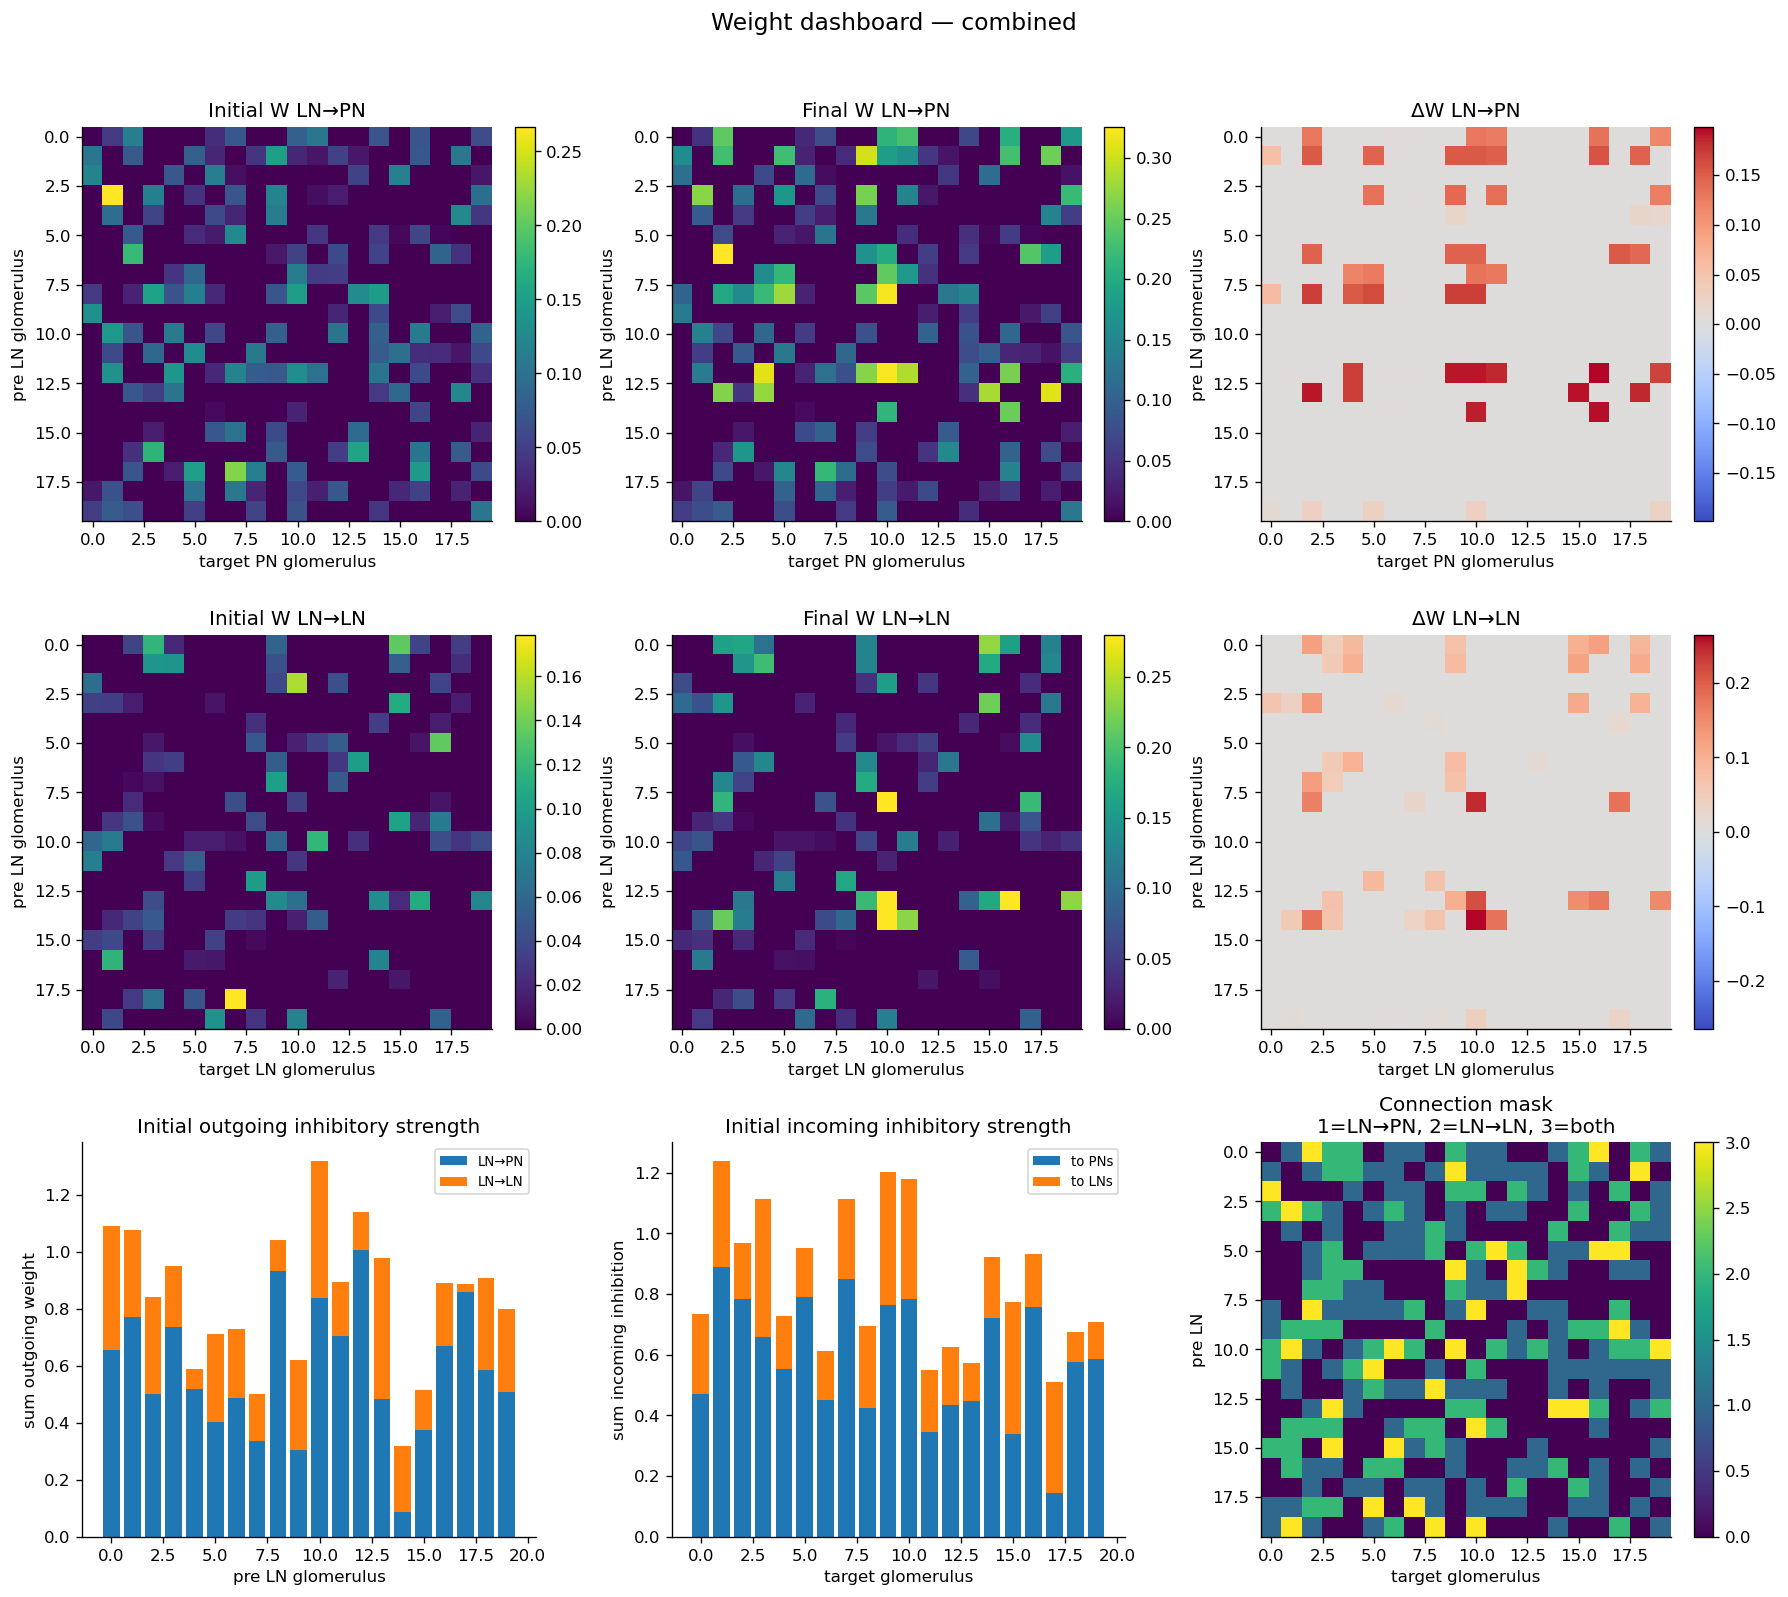

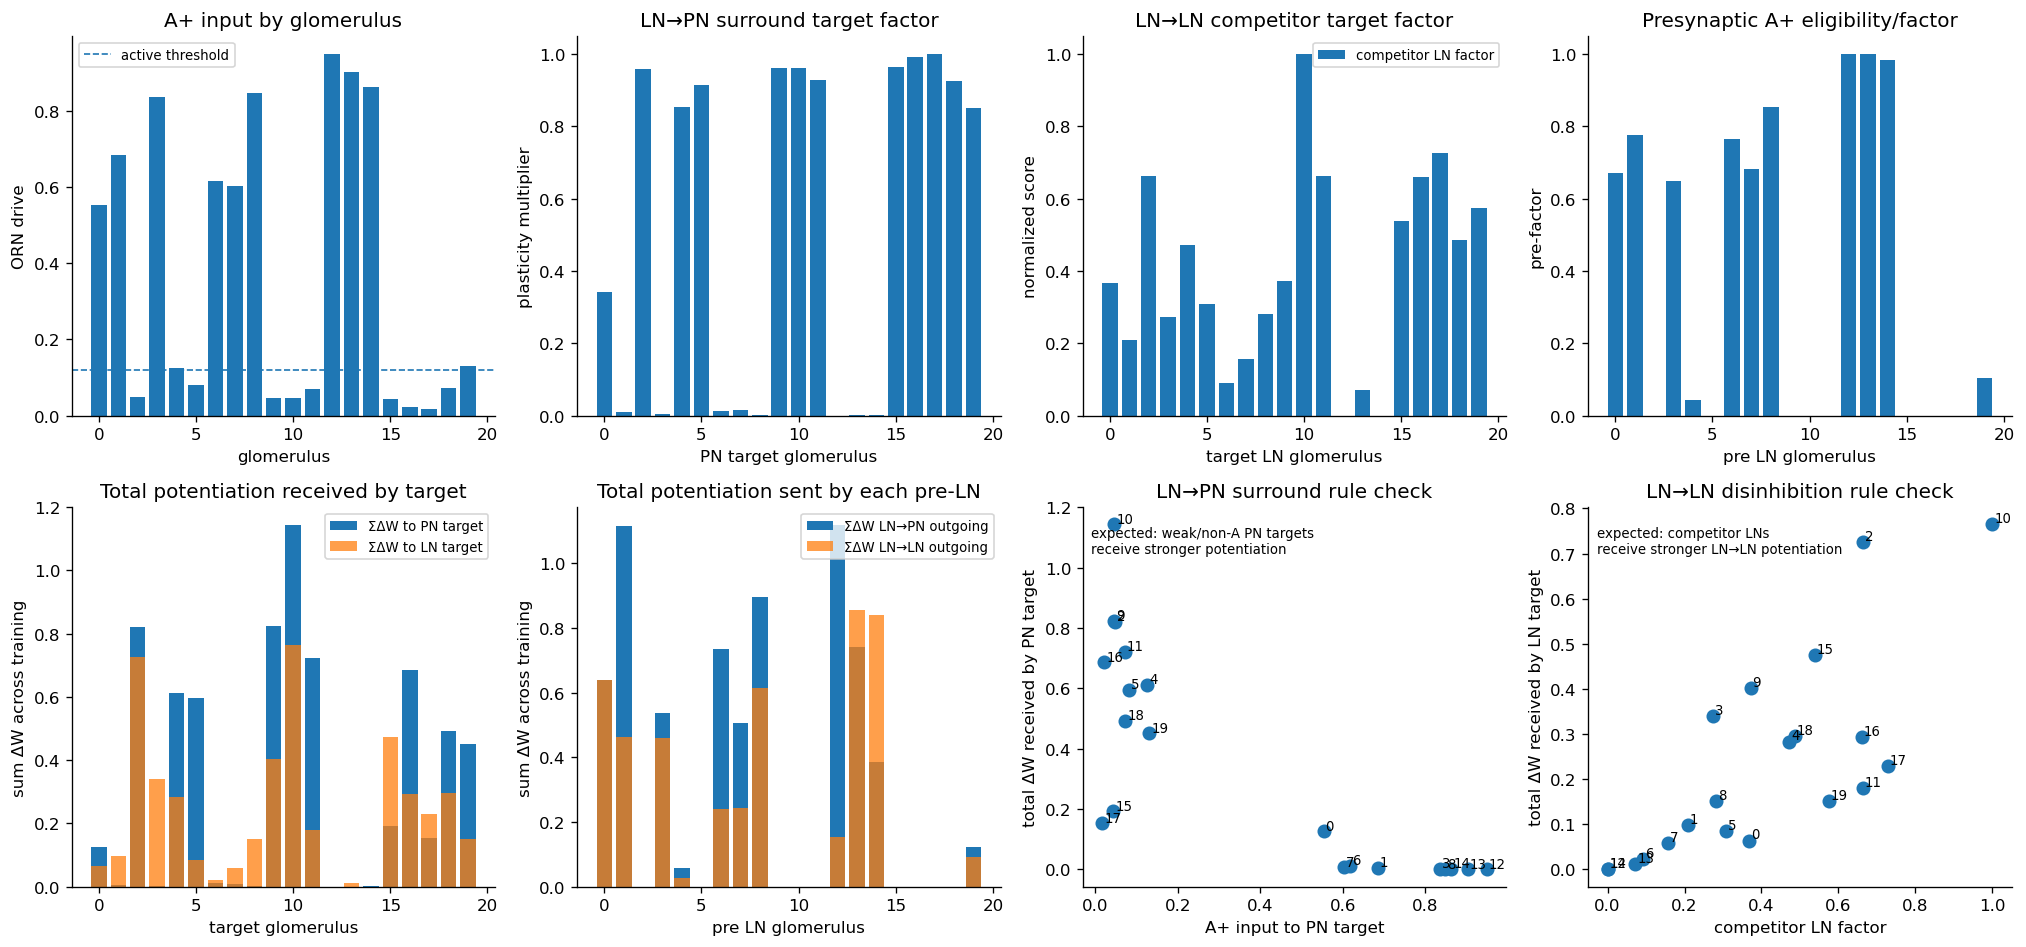

In [11]:
def plot_weight_dashboard(result):
    Wlp0 = result["W_LNPN_history"][0]
    Wll0 = result["W_LNLN_history"][0]
    WlpF = result["W_LNPN_history"][-1]
    WllF = result["W_LNLN_history"][-1]
    dWlp = WlpF - Wlp0
    dWll = WllF - Wll0

    fig, axes = plt.subplots(3, 3, figsize=(15, 13))

    mats = [
        (Wlp0, "Initial W LN→PN", "target PN glomerulus"),
        (WlpF, "Final W LN→PN", "target PN glomerulus"),
        (dWlp, "ΔW LN→PN", "target PN glomerulus"),
        (Wll0, "Initial W LN→LN", "target LN glomerulus"),
        (WllF, "Final W LN→LN", "target LN glomerulus"),
        (dWll, "ΔW LN→LN", "target LN glomerulus"),
    ]

    for ax, (mat, title, xlabel) in zip(axes.flat[:6], mats):
        if "ΔW" in title:
            vmax = np.nanmax(np.abs(mat)) + 1e-12
            im = ax.imshow(mat, aspect="auto", cmap="coolwarm", vmin=-vmax, vmax=vmax)
        else:
            im = ax.imshow(mat, aspect="auto")
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("pre LN glomerulus")
        fig.colorbar(im, ax=ax, fraction=0.046)

    ax = axes[2, 0]
    out_lp = Wlp0.sum(axis=1)
    out_ll = Wll0.sum(axis=1)
    ax.bar(np.arange(P.n_glom), out_lp, label="LN→PN")
    ax.bar(np.arange(P.n_glom), out_ll, bottom=out_lp, label="LN→LN")
    ax.set_title("Initial outgoing inhibitory strength")
    ax.set_xlabel("pre LN glomerulus")
    ax.set_ylabel("sum outgoing weight")
    ax.legend(fontsize=8)

    ax = axes[2, 1]
    in_lp = Wlp0.sum(axis=0)
    in_ll = Wll0.sum(axis=0)
    ax.bar(np.arange(P.n_glom), in_lp, label="to PNs")
    ax.bar(np.arange(P.n_glom), in_ll, bottom=in_lp, label="to LNs")
    ax.set_title("Initial incoming inhibitory strength")
    ax.set_xlabel("target glomerulus")
    ax.set_ylabel("sum incoming inhibition")
    ax.legend(fontsize=8)

    ax = axes[2, 2]
    mask_code = result["net"]["mask_LNPN"].astype(int) + 2 * result["net"]["mask_LNLN"].astype(int)
    im = ax.imshow(mask_code, aspect="auto", vmin=0, vmax=3)
    ax.set_title("Connection mask\n1=LN→PN, 2=LN→LN, 3=both")
    ax.set_xlabel("target glomerulus")
    ax.set_ylabel("pre LN")
    fig.colorbar(im, ax=ax, fraction=0.046)

    fig.suptitle(f"Weight dashboard — {result['condition']}", y=1.02, fontsize=14)
    fig.tight_layout()
    savefig(fig, f"04_weight_dashboard_{result['condition']}")

def plot_plasticity_rule_dashboard(result):
    odors = result["odors"]
    A = odors["A+"]

    diag = result["diag_history"][-1] if len(result["diag_history"]) else {
        "pre_factor": np.zeros(P.n_glom),
        "target_surround": np.zeros(P.n_glom),
        "competitor_factor": np.zeros(P.n_glom),
    }

    dWlp_total = np.sum(result["W_LNPN_history"][-1] - result["W_LNPN_history"][0], axis=0)
    dWll_total = np.sum(result["W_LNLN_history"][-1] - result["W_LNLN_history"][0], axis=0)
    dWlp_out = np.sum(result["W_LNPN_history"][-1] - result["W_LNPN_history"][0], axis=1)
    dWll_out = np.sum(result["W_LNLN_history"][-1] - result["W_LNLN_history"][0], axis=1)

    fig, axes = plt.subplots(2, 4, figsize=(17, 8))

    ax = axes[0, 0]
    ax.bar(np.arange(P.n_glom), A)
    ax.axhline(P.active_thr, linestyle="--", linewidth=1, label="active threshold")
    ax.set_title("A+ input by glomerulus")
    ax.set_xlabel("glomerulus")
    ax.set_ylabel("ORN drive")
    ax.legend(fontsize=8)

    ax = axes[0, 1]
    ax.bar(np.arange(P.n_glom), diag["target_surround"])
    ax.set_title("LN→PN surround target factor")
    ax.set_xlabel("PN target glomerulus")
    ax.set_ylabel("plasticity multiplier")

    ax = axes[0, 2]
    ax.bar(np.arange(P.n_glom), diag["competitor_factor"], label="competitor LN factor")
    ax.set_title("LN→LN competitor target factor")
    ax.set_xlabel("target LN glomerulus")
    ax.set_ylabel("normalized score")
    ax.legend(fontsize=8)

    ax = axes[0, 3]
    ax.bar(np.arange(P.n_glom), diag["pre_factor"])
    ax.set_title("Presynaptic A+ eligibility/factor")
    ax.set_xlabel("pre LN glomerulus")
    ax.set_ylabel("pre-factor")

    ax = axes[1, 0]
    ax.bar(np.arange(P.n_glom), dWlp_total, label="ΣΔW to PN target")
    ax.bar(np.arange(P.n_glom), dWll_total, label="ΣΔW to LN target", alpha=0.75)
    ax.set_title("Total potentiation received by target")
    ax.set_xlabel("target glomerulus")
    ax.set_ylabel("sum ΔW across training")
    ax.legend(fontsize=8)

    ax = axes[1, 1]
    ax.bar(np.arange(P.n_glom), dWlp_out, label="ΣΔW LN→PN outgoing")
    ax.bar(np.arange(P.n_glom), dWll_out, label="ΣΔW LN→LN outgoing", alpha=0.75)
    ax.set_title("Total potentiation sent by each pre-LN")
    ax.set_xlabel("pre LN glomerulus")
    ax.set_ylabel("sum ΔW across training")
    ax.legend(fontsize=8)

    ax = axes[1, 2]
    ax.scatter(A, dWlp_total, s=55)
    for g in range(P.n_glom):
        ax.text(A[g] + 0.005, dWlp_total[g] + 0.005, str(g), fontsize=8)
    ax.set_title("LN→PN surround rule check")
    ax.set_xlabel("A+ input to PN target")
    ax.set_ylabel("total ΔW received by PN target")
    ax.text(0.02, 0.95, "expected: weak/non-A PN targets\nreceive stronger potentiation",
            transform=ax.transAxes, va="top", fontsize=8)

    ax = axes[1, 3]
    ax.scatter(diag["competitor_factor"], dWll_total, s=55)
    for g in range(P.n_glom):
        ax.text(diag["competitor_factor"][g] + 0.005, dWll_total[g] + 0.005, str(g), fontsize=8)
    ax.set_title("LN→LN disinhibition rule check")
    ax.set_xlabel("competitor LN factor")
    ax.set_ylabel("total ΔW received by LN target")
    ax.text(0.02, 0.95, "expected: competitor LNs\nreceive stronger LN→LN potentiation",
            transform=ax.transAxes, va="top", fontsize=8)

    fig.tight_layout()
    savefig(fig, f"05_plasticity_rule_dashboard_{result['condition']}")

plot_weight_dashboard(results["combined"])
plot_plasticity_rule_dashboard(results["combined"])

## 12. Training dynamics, test dashboards, and representational metrics

In [12]:
def category_masks(categories):
    masks = {}
    for cat in CATEGORY_ORDER:
        masks[cat] = np.array(categories) == cat
    return masks

def mean_by_mask(values, mask):
    if np.sum(mask) == 0:
        return np.nan
    return float(np.nanmean(np.asarray(values)[mask]))

def collect_training_summary(results):
    rows = []
    for cond, res in results.items():
        cats = res["categories"]
        masks = category_masks(cats)

        for state_i in range(P.n_trials + 1):
            Wlp = res["W_LNPN_history"][state_i]
            Wll = res["W_LNLN_history"][state_i]
            tests = evaluate_odors(res["odors"], Wlp, Wll, P)

            for pop in POPULATIONS:
                A_resp = tests["A+"][pop]
                M_resp = tests["Mix"][pop]

                rows.append({
                    "condition": cond,
                    "weight_state": state_i,
                    "population": pop,
                    "A_only_mean_A_train": mean_by_mask(A_resp, masks["A_only"]),
                    "nonA_mean_A_train": np.nanmean([
                        mean_by_mask(A_resp, masks["B_only"]),
                        mean_by_mask(A_resp, masks["weak_candidate"]),
                        mean_by_mask(A_resp, masks["background"]),
                    ]),
                    "contrast_A_minus_nonA": mean_by_mask(A_resp, masks["A_only"]) - np.nanmean([
                        mean_by_mask(A_resp, masks["B_only"]),
                        mean_by_mask(A_resp, masks["weak_candidate"]),
                        mean_by_mask(A_resp, masks["background"]),
                    ]),
                    "A_only_mean_Mix": mean_by_mask(M_resp, masks["A_only"]),
                    "B_only_mean_Mix": mean_by_mask(M_resp, masks["B_only"]),
                    "overlap_mean_Mix": mean_by_mask(M_resp, masks["overlap"]),
                    "background_mean_Mix": mean_by_mask(M_resp, masks["background"]),
                    "sum_W_LNPN": Wlp.sum(),
                    "sum_W_LNLN": Wll.sum(),
                })
    df = pd.DataFrame(rows)
    save_table(df, "training_summary")
    return df

training_df = collect_training_summary(results)
display(training_df.head())

,condition,weight_state,population,A_only_mean_A_train,nonA_mean_A_train,contrast_A_minus_nonA,A_only_mean_Mix,B_only_mean_Mix,overlap_mean_Mix,background_mean_Mix,sum_W_LNPN,sum_W_LNLN
0,static,0,PN,20.045695,0.00000,20.045695,14.313635,12.294759,7.518459,0.100500,11.765486,5.040389
1,static,0,LN,33.001118,3.28723,29.713888,32.560209,31.699394,25.139280,2.244865,11.765486,5.040389
2,static,1,PN,20.045695,0.00000,20.045695,14.313635,12.294759,7.518459,0.100500,11.765486,5.040389
3,static,1,LN,33.001118,3.28723,29.713888,32.560209,31.699394,25.139280,2.244865,11.765486,5.040389
4,static,2,PN,20.045695,0.00000,20.045695,14.313635,12.294759,7.518459,0.100500,11.765486,5.040389


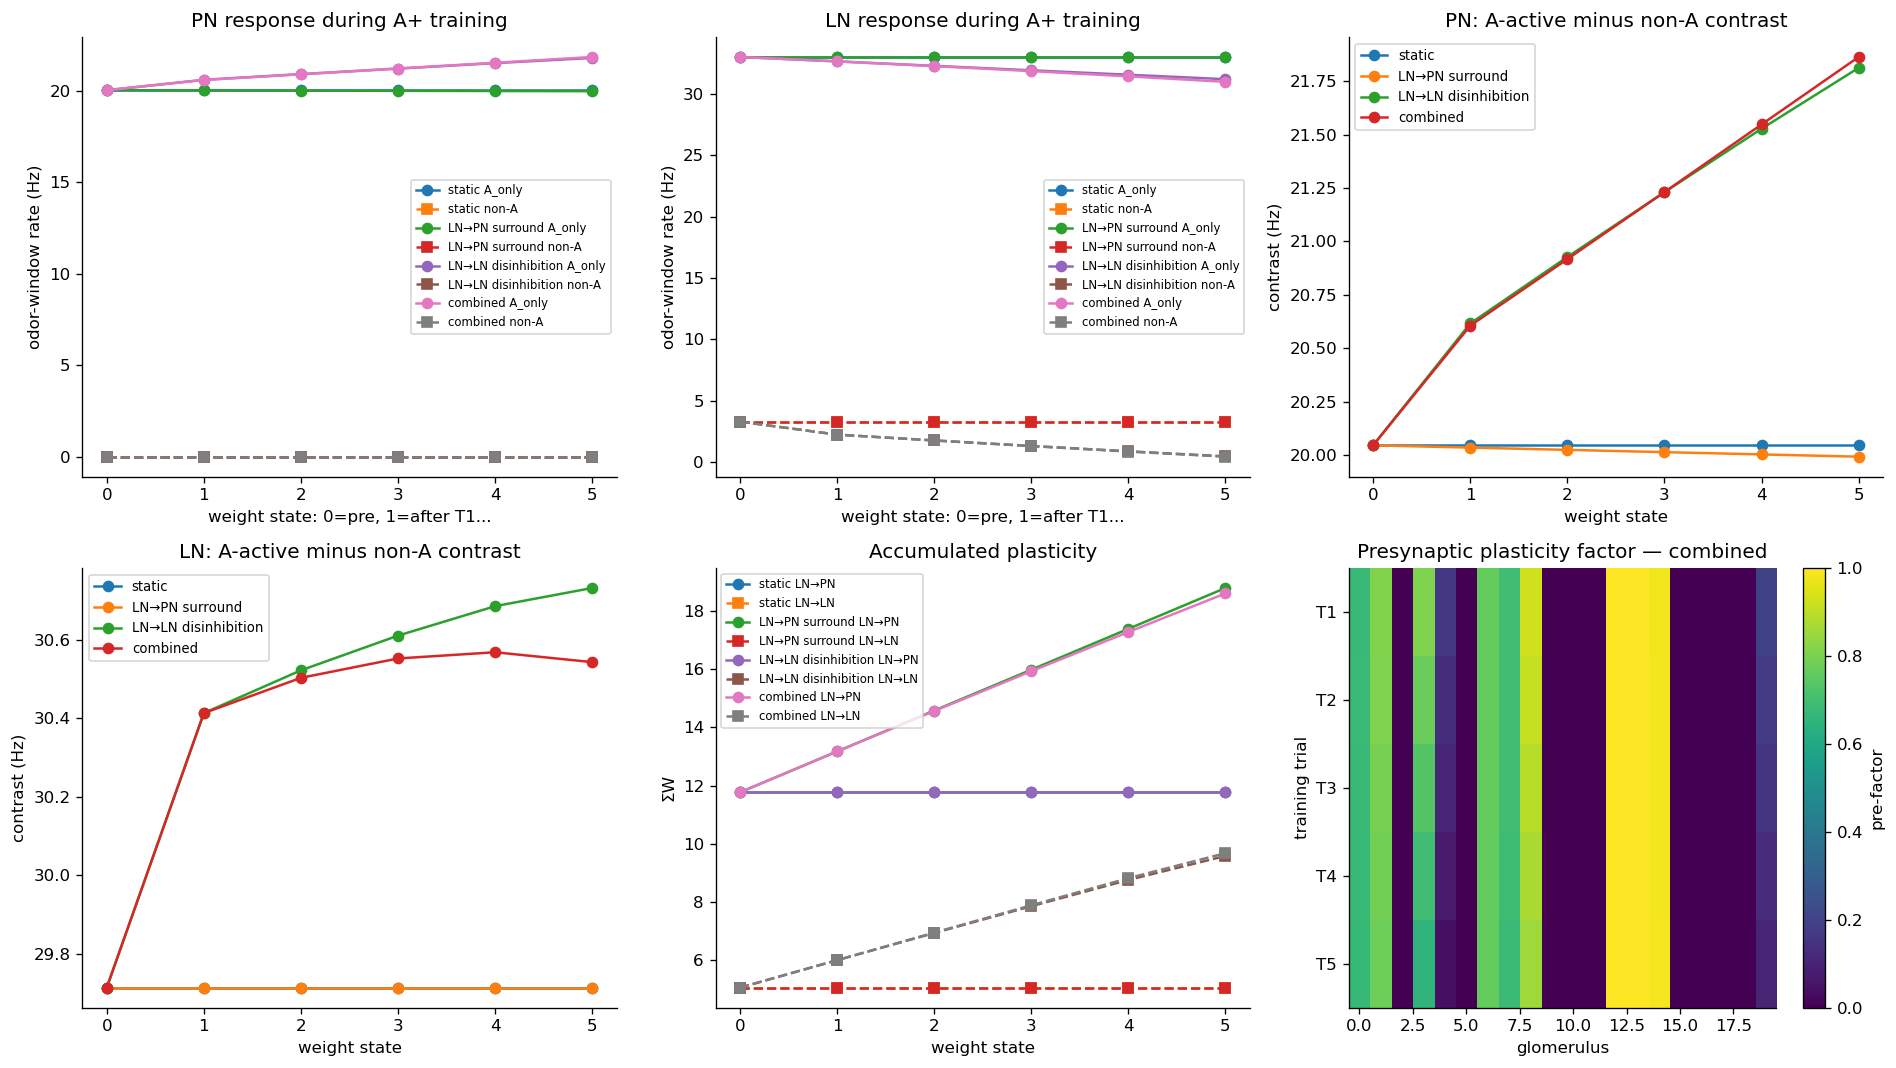

In [13]:
def plot_training_summary(training_df):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))

    for pop, ax in zip(["PN", "LN"], axes[0, :2]):
        sub = training_df[training_df["population"] == pop]
        for cond in CONDITIONS:
            s = sub[sub["condition"] == cond]
            ax.plot(s["weight_state"], s["A_only_mean_A_train"], marker="o", label=f"{cond} A_only")
            ax.plot(s["weight_state"], s["nonA_mean_A_train"], marker="s", linestyle="--", label=f"{cond} non-A")
        ax.set_title(f"{pop} response during A+ training")
        ax.set_xlabel("weight state: 0=pre, 1=after T1...")
        ax.set_ylabel("odor-window rate (Hz)")
        ax.legend(fontsize=7)

    ax = axes[0, 2]
    sub = training_df[training_df["population"] == "PN"]
    for cond in CONDITIONS:
        s = sub[sub["condition"] == cond]
        ax.plot(s["weight_state"], s["contrast_A_minus_nonA"], marker="o", label=cond)
    ax.set_title("PN: A-active minus non-A contrast")
    ax.set_xlabel("weight state")
    ax.set_ylabel("contrast (Hz)")
    ax.legend(fontsize=8)

    ax = axes[1, 0]
    sub = training_df[training_df["population"] == "LN"]
    for cond in CONDITIONS:
        s = sub[sub["condition"] == cond]
        ax.plot(s["weight_state"], s["contrast_A_minus_nonA"], marker="o", label=cond)
    ax.set_title("LN: A-active minus non-A contrast")
    ax.set_xlabel("weight state")
    ax.set_ylabel("contrast (Hz)")
    ax.legend(fontsize=8)

    ax = axes[1, 1]
    for cond in CONDITIONS:
        s = training_df[(training_df["condition"] == cond) & (training_df["population"] == "PN")]
        ax.plot(s["weight_state"], s["sum_W_LNPN"], marker="o", label=f"{cond} LN→PN")
        ax.plot(s["weight_state"], s["sum_W_LNLN"], marker="s", linestyle="--", label=f"{cond} LN→LN")
    ax.set_title("Accumulated plasticity")
    ax.set_xlabel("weight state")
    ax.set_ylabel("ΣW")
    ax.legend(fontsize=7)

    ax = axes[1, 2]
    res = results["combined"]
    pre_factors = np.array([d["pre_factor"] for d in res["diag_history"]])
    im = ax.imshow(pre_factors, aspect="auto", vmin=0, vmax=1)
    ax.set_title("Presynaptic plasticity factor — combined")
    ax.set_xlabel("glomerulus")
    ax.set_ylabel("training trial")
    ax.set_yticks(range(P.n_trials))
    ax.set_yticklabels([f"T{i}" for i in range(1, P.n_trials + 1)])
    fig.colorbar(im, ax=ax, label="pre-factor")

    fig.tight_layout()
    savefig(fig, "06_training_summary")

plot_training_summary(training_df)

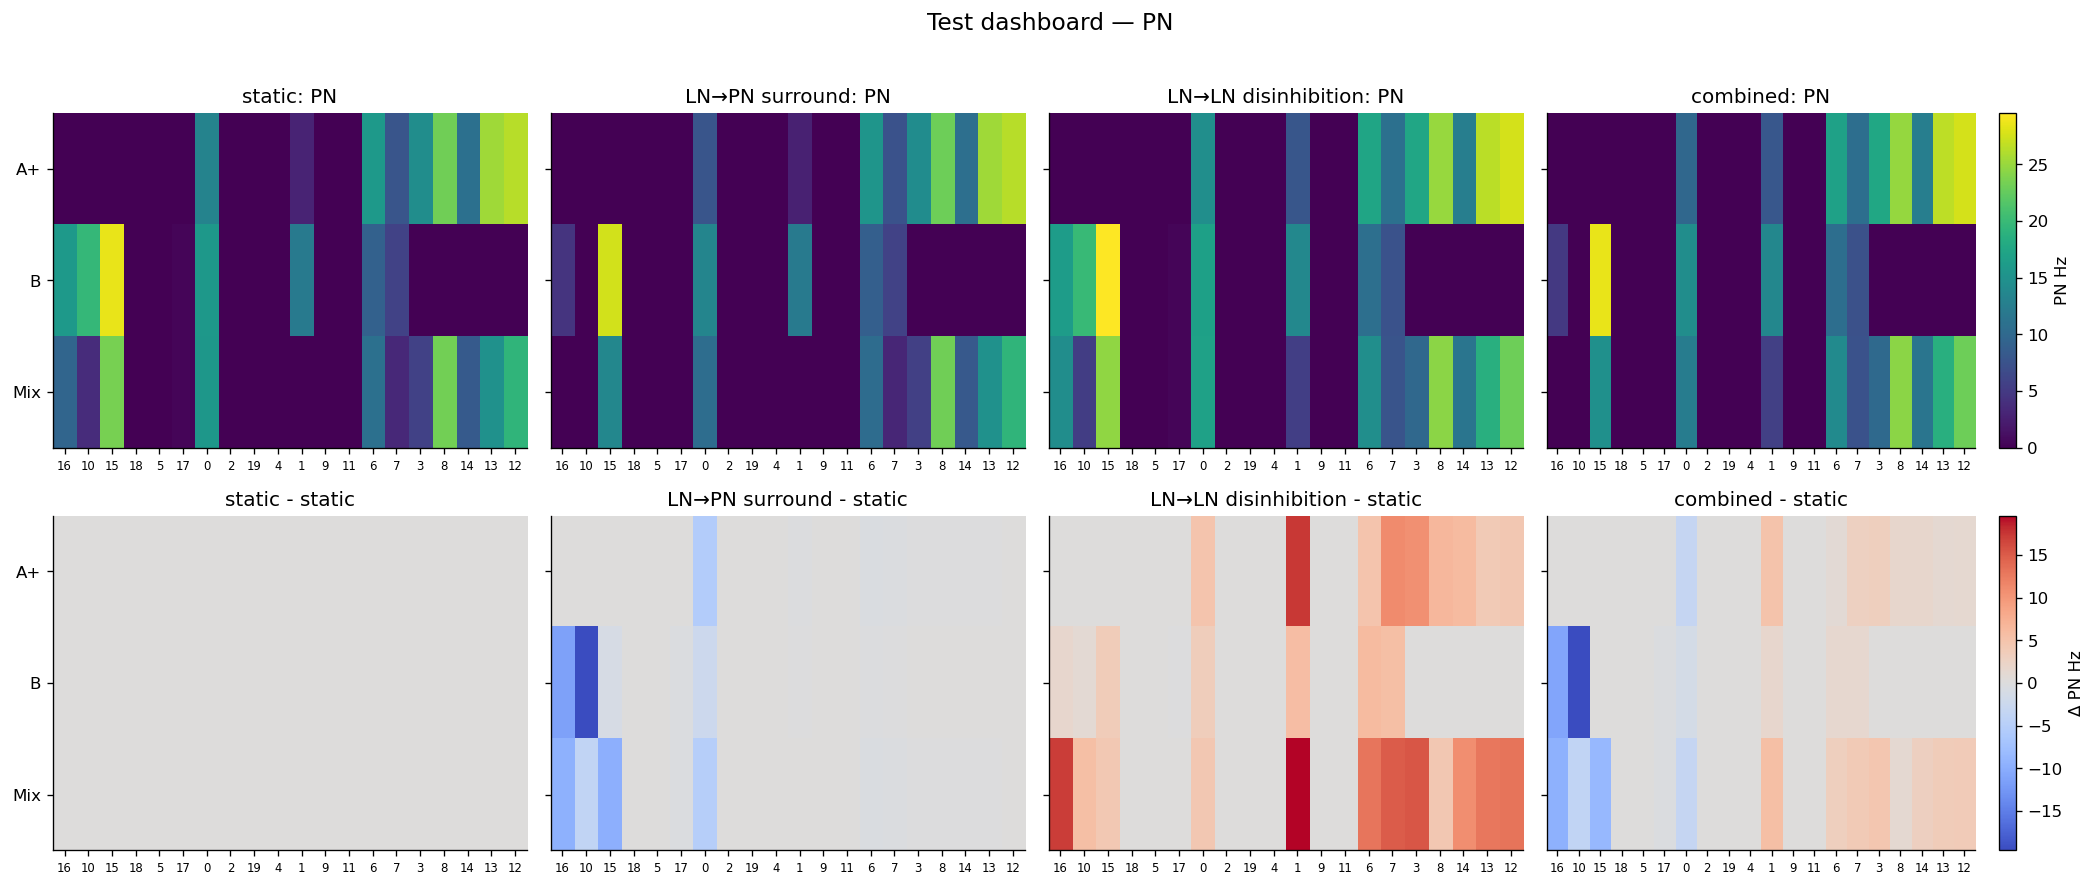

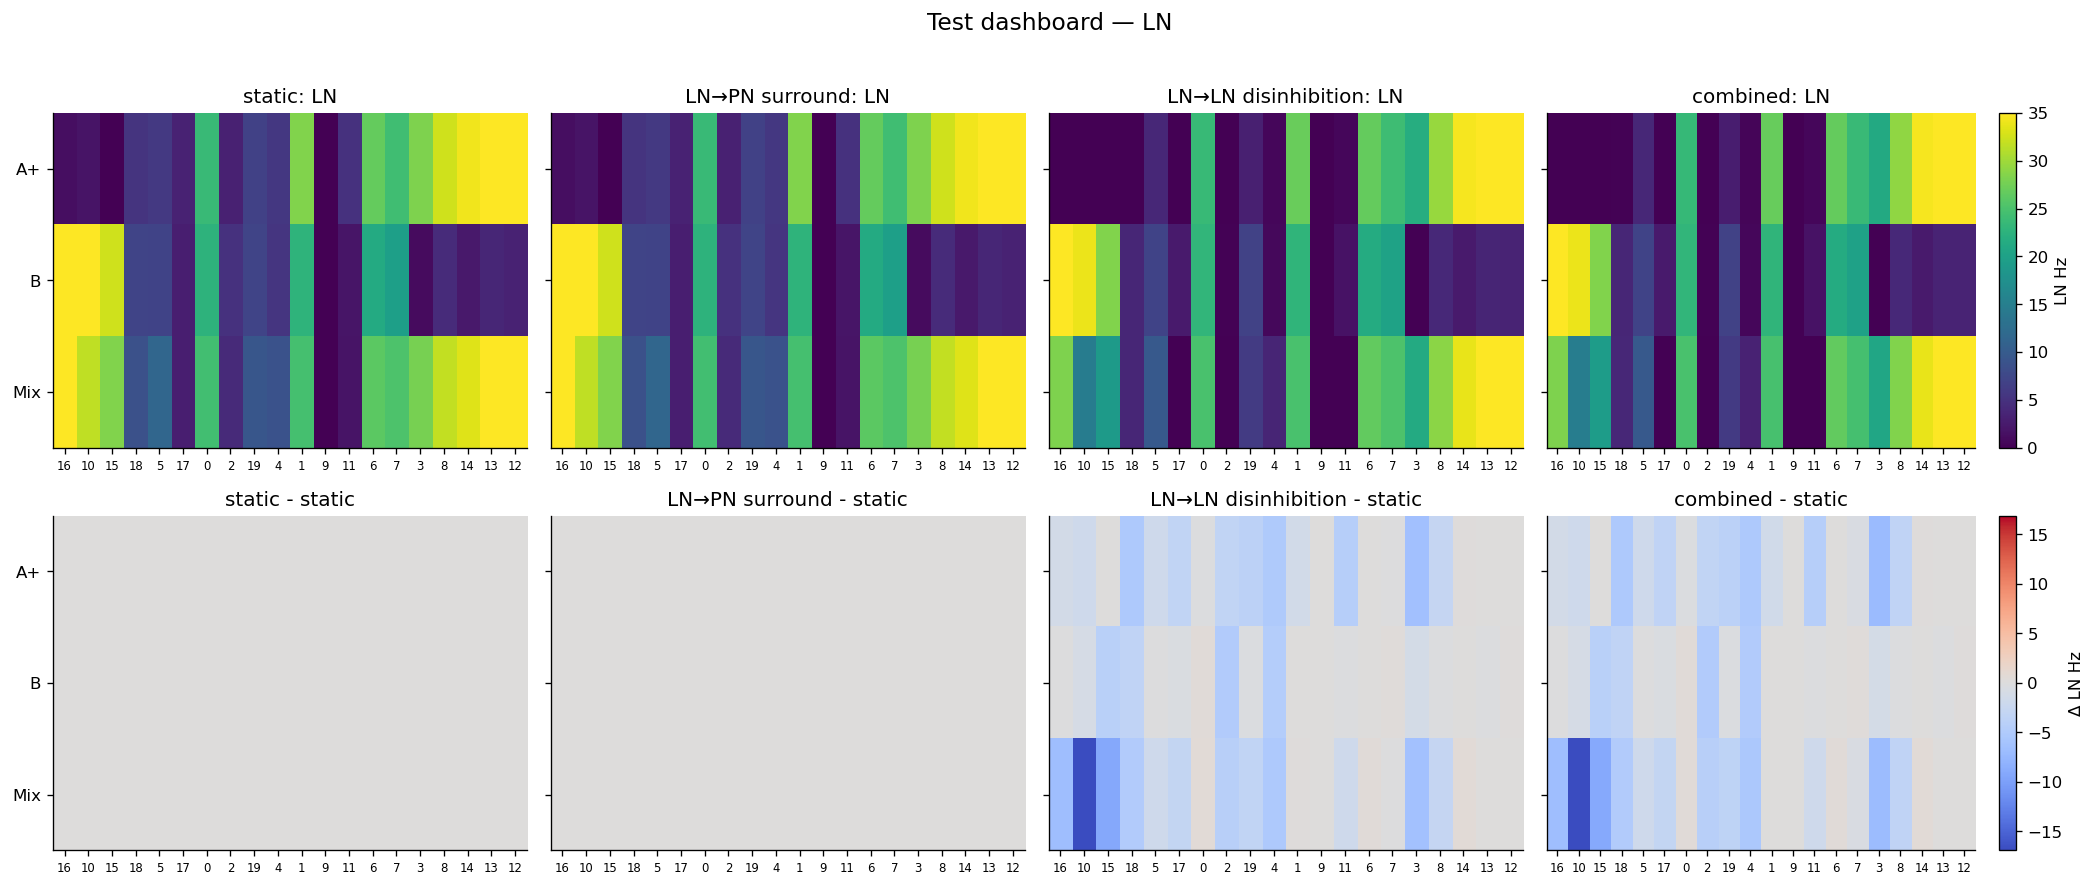

In [14]:
def response_matrix(result, population="PN", state="post"):
    return np.vstack([result[state][odor][population] for odor in ODORS])

def plot_test_dashboard(results, population="PN"):
    order = order_glomeruli_for_display(results["static"]["odors"])
    base = response_matrix(results["static"], population=population, state="post")[:, order]

    fig, axes = plt.subplots(2, len(CONDITIONS), figsize=(4.4 * len(CONDITIONS), 7.2))

    top_mats = [response_matrix(results[cond], population=population, state="post")[:, order] for cond in CONDITIONS]
    vmax = max(np.nanmax(m) for m in top_mats)

    for j, cond in enumerate(CONDITIONS):
        mat = top_mats[j]
        ax = axes[0, j]
        im = ax.imshow(mat, aspect="auto", vmin=0, vmax=vmax)
        ax.set_title(f"{cond}: {population}")
        ax.set_yticks(range(3))
        ax.set_yticklabels(ODORS if j == 0 else [])
        ax.set_xticks(range(P.n_glom))
        ax.set_xticklabels(order, fontsize=7)
        if j == len(CONDITIONS) - 1:
            fig.colorbar(im, ax=ax, label=f"{population} Hz", fraction=0.046)

        diff = mat - base
        ax = axes[1, j]
        vmax_diff = np.nanmax(np.abs(diff)) + 1e-12
        im2 = ax.imshow(diff, aspect="auto", cmap="coolwarm", vmin=-vmax_diff, vmax=vmax_diff)
        ax.set_title(f"{cond} - static")
        ax.set_yticks(range(3))
        ax.set_yticklabels(ODORS if j == 0 else [])
        ax.set_xticks(range(P.n_glom))
        ax.set_xticklabels(order, fontsize=7)
        if j == len(CONDITIONS) - 1:
            fig.colorbar(im2, ax=ax, label=f"Δ {population} Hz", fraction=0.046)

    fig.suptitle(f"Test dashboard — {population}", y=1.02, fontsize=14)
    fig.tight_layout()
    savefig(fig, f"07_test_dashboard_{population}")

plot_test_dashboard(results, population="PN")
plot_test_dashboard(results, population="LN")

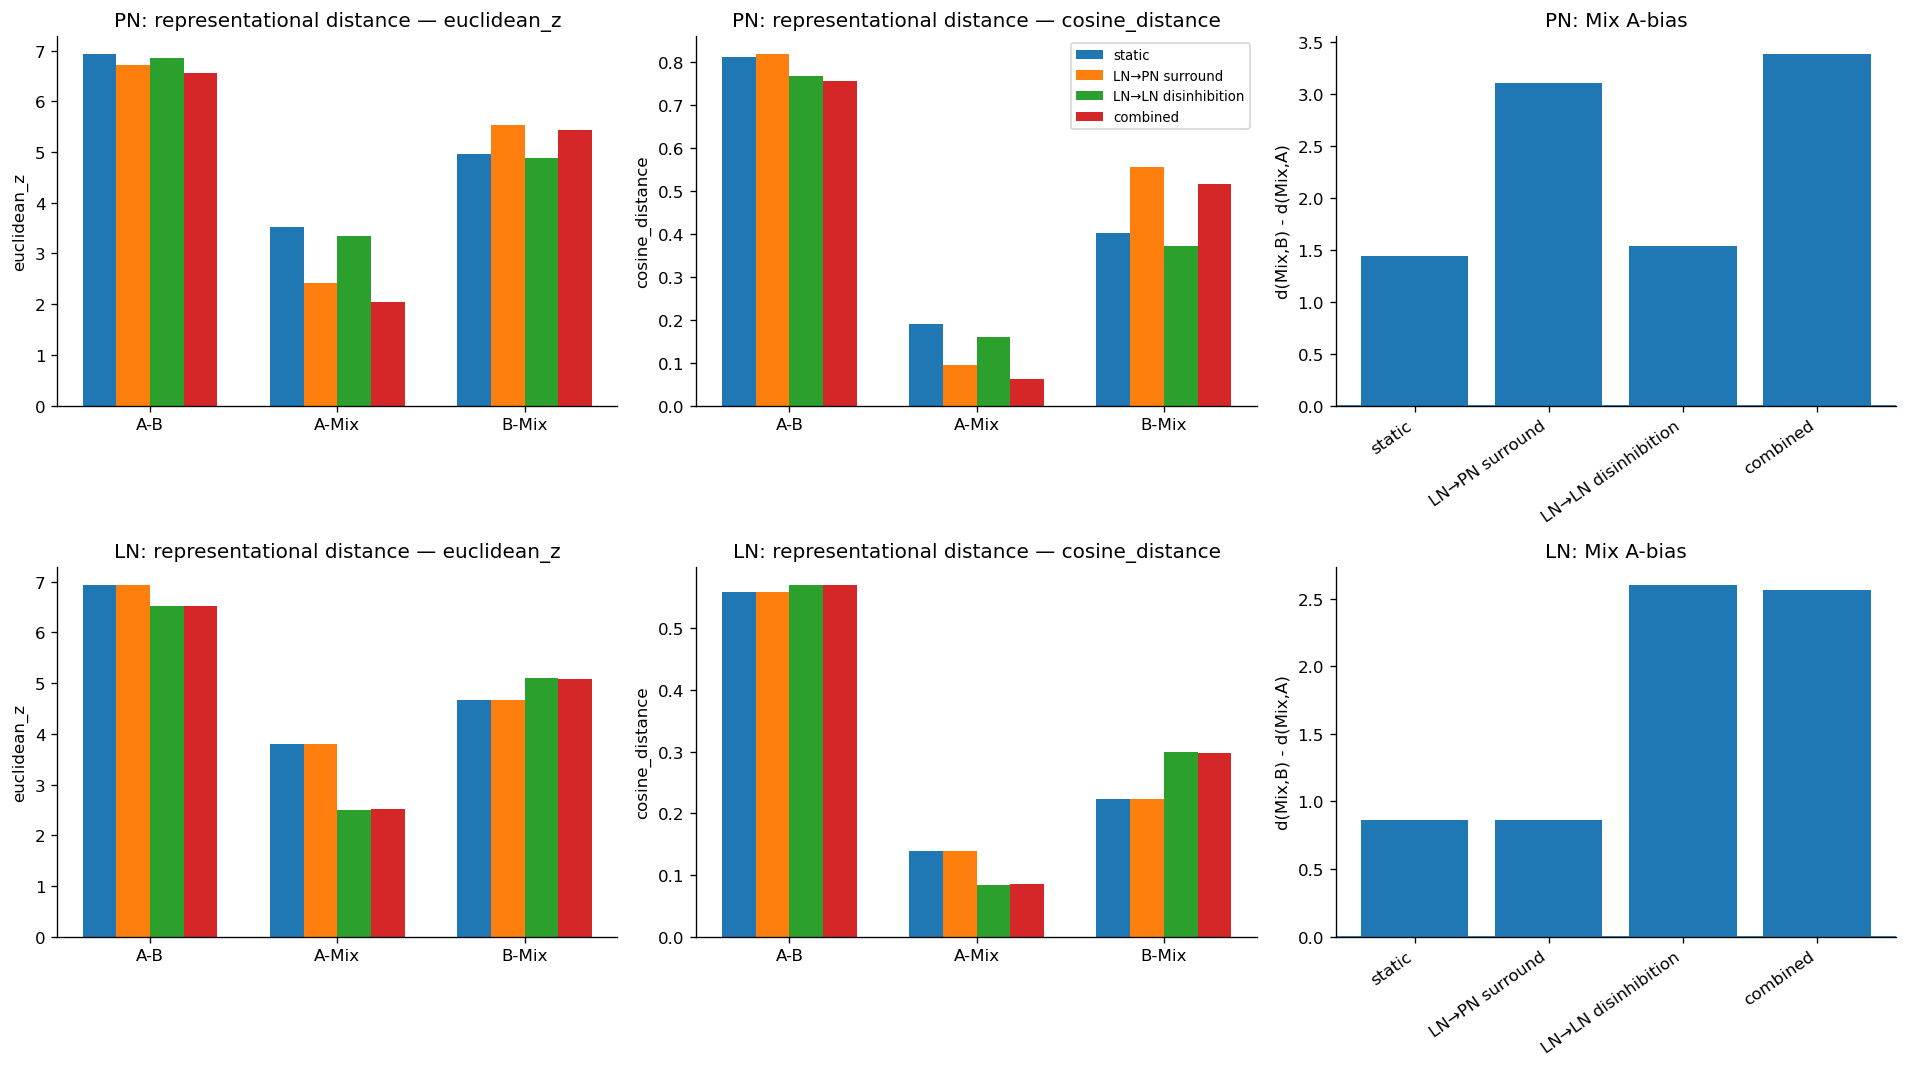

In [15]:
def plot_distance_dashboard(distance_df, state="post"):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    metric_labels = ["euclidean_z", "cosine_distance"]
    pairs = ["A-B", "A-Mix", "B-Mix"]

    for row, pop in enumerate(["PN", "LN"]):
        for col, metric in enumerate(metric_labels):
            ax = axes[row, col]
            sub = distance_df[
                (distance_df["state"] == state)
                & (distance_df["population"] == pop)
                & (distance_df["metric"] == metric)
                & (distance_df["pair"].isin(pairs))
            ]
            pivot = sub.pivot_table(index="condition", columns="pair", values="value", aggfunc="mean")
            pivot = pivot.reindex(index=CONDITIONS, columns=pairs)

            x = np.arange(len(pairs))
            width = 0.18
            for i, cond in enumerate(CONDITIONS):
                vals = pivot.loc[cond].values.astype(float)
                ax.bar(x + (i - 1.5) * width, vals, width=width, label=cond)

            ax.set_title(f"{pop}: representational distance — {metric}")
            ax.set_xticks(x)
            ax.set_xticklabels(pairs)
            ax.set_ylabel(metric)
            if row == 0 and col == 1:
                ax.legend(fontsize=8)

        ax = axes[row, 2]
        sub = distance_df[
            (distance_df["state"] == state)
            & (distance_df["population"] == pop)
            & (distance_df["metric"] == "euclidean_z")
            & (distance_df["pair"] == "Mix A-bias")
        ]
        pivot = sub.set_index("condition").reindex(CONDITIONS)
        ax.bar(range(len(CONDITIONS)), pivot["value"].values)
        ax.axhline(0, linewidth=1)
        ax.set_xticks(range(len(CONDITIONS)))
        ax.set_xticklabels(CONDITIONS, rotation=35, ha="right")
        ax.set_ylabel("d(Mix,B) - d(Mix,A)")
        ax.set_title(f"{pop}: Mix A-bias")

    fig.tight_layout()
    savefig(fig, "08_distance_dashboard")

plot_distance_dashboard(distance_df, state="post")

## 13. Temporal traces, latency, and AUC

In [16]:
def simulate_trace_from_rates(rate_vec, p=P, seed=0):
    """
    Generate a simple first-order trace from a target rate vector.
    This is not a spiking simulation; it is a temporal visualization of the rate-model output.
    """
    rng = np.random.default_rng(seed)
    t = np.arange(-p.t_pre_ms, p.t_odor_ms + p.t_post_ms + p.dt_ms, p.dt_ms)
    n_t = len(t)
    n = len(rate_vec)

    baseline = np.full(n, p.base_pn + 1.0)
    trace = np.zeros((n_t, n))
    trace[0] = baseline + rng.normal(0, p.trace_noise_sd, n)

    for i in range(1, n_t):
        target = rate_vec if (0 <= t[i] <= p.t_odor_ms) else baseline
        tau = p.tau_on_ms if (0 <= t[i] <= p.t_odor_ms) else p.tau_off_ms
        trace[i] = trace[i-1] + (p.dt_ms / tau) * (target - trace[i-1])
        trace[i] += rng.normal(0, p.trace_noise_sd, n)

    return t, np.clip(trace, 0.0, None)

def compute_latency_features(t, trace, p=P):
    baseline_mask = t < 0
    odor_mask = (t >= 0) & (t <= p.t_odor_ms)
    early_mask = (t >= 0) & (t < 150)
    late_mask = (t >= 150) & (t < 500)

    baseline = trace[baseline_mask].mean(axis=0)
    delta = trace - baseline

    odor_delta = delta[odor_mask]
    odor_t = t[odor_mask]

    peak = np.maximum(odor_delta.max(axis=0), 0.0)
    latency = np.full(trace.shape[1], np.nan)

    for g in range(trace.shape[1]):
        if peak[g] <= 1e-9:
            continue
        threshold = 0.5 * peak[g]
        idx = np.where(odor_delta[:, g] >= threshold)[0]
        if len(idx):
            latency[g] = odor_t[idx[0]]

    auc_early = trapz_compat(np.maximum(delta[early_mask], 0.0), dx=p.dt_ms, axis=0) / 1000.0
    auc_late = trapz_compat(np.maximum(delta[late_mask], 0.0), dx=p.dt_ms, axis=0) / 1000.0

    return {
        "peak_delta": peak,
        "latency50_ms": latency,
        "auc_early": auc_early,
        "auc_late": auc_late,
    }

def collect_temporal_features(results, odor="A+", state="post"):
    rows = []
    for cond, res in results.items():
        for pop in POPULATIONS:
            vec = get_response(res, odor, population=pop, state=state)
            t, trace = simulate_trace_from_rates(vec, P, seed=res["seed"] + hash(cond + pop) % 10000)
            feats = compute_latency_features(t, trace, P)
            for g in range(P.n_glom):
                rows.append({
                    "condition": cond,
                    "population": pop,
                    "odor": odor,
                    "glomerulus": g,
                    "category": res["categories"][g],
                    "latency50_ms": feats["latency50_ms"][g],
                    "auc_early": feats["auc_early"][g],
                    "auc_late": feats["auc_late"][g],
                    "peak_delta": feats["peak_delta"][g],
                })
    df = pd.DataFrame(rows)
    save_table(df, "temporal_features")
    return df

temporal_df = collect_temporal_features(results, odor="A+")
display(temporal_df.head())

,condition,population,odor,glomerulus,category,latency50_ms,auc_early,auc_late,peak_delta
0,static,PN,A+,0,overlap,40.0,0.987443,3.528853,10.993955
1,static,PN,A+,1,overlap,205.0,0.002356,0.034073,0.490835
2,static,PN,A+,2,background,NaN,0.000000,0.000000,0.000000
3,static,PN,A+,3,A_only,35.0,1.119124,3.771867,11.585637
4,static,PN,A+,4,weak_candidate,NaN,0.000000,0.000000,0.000000


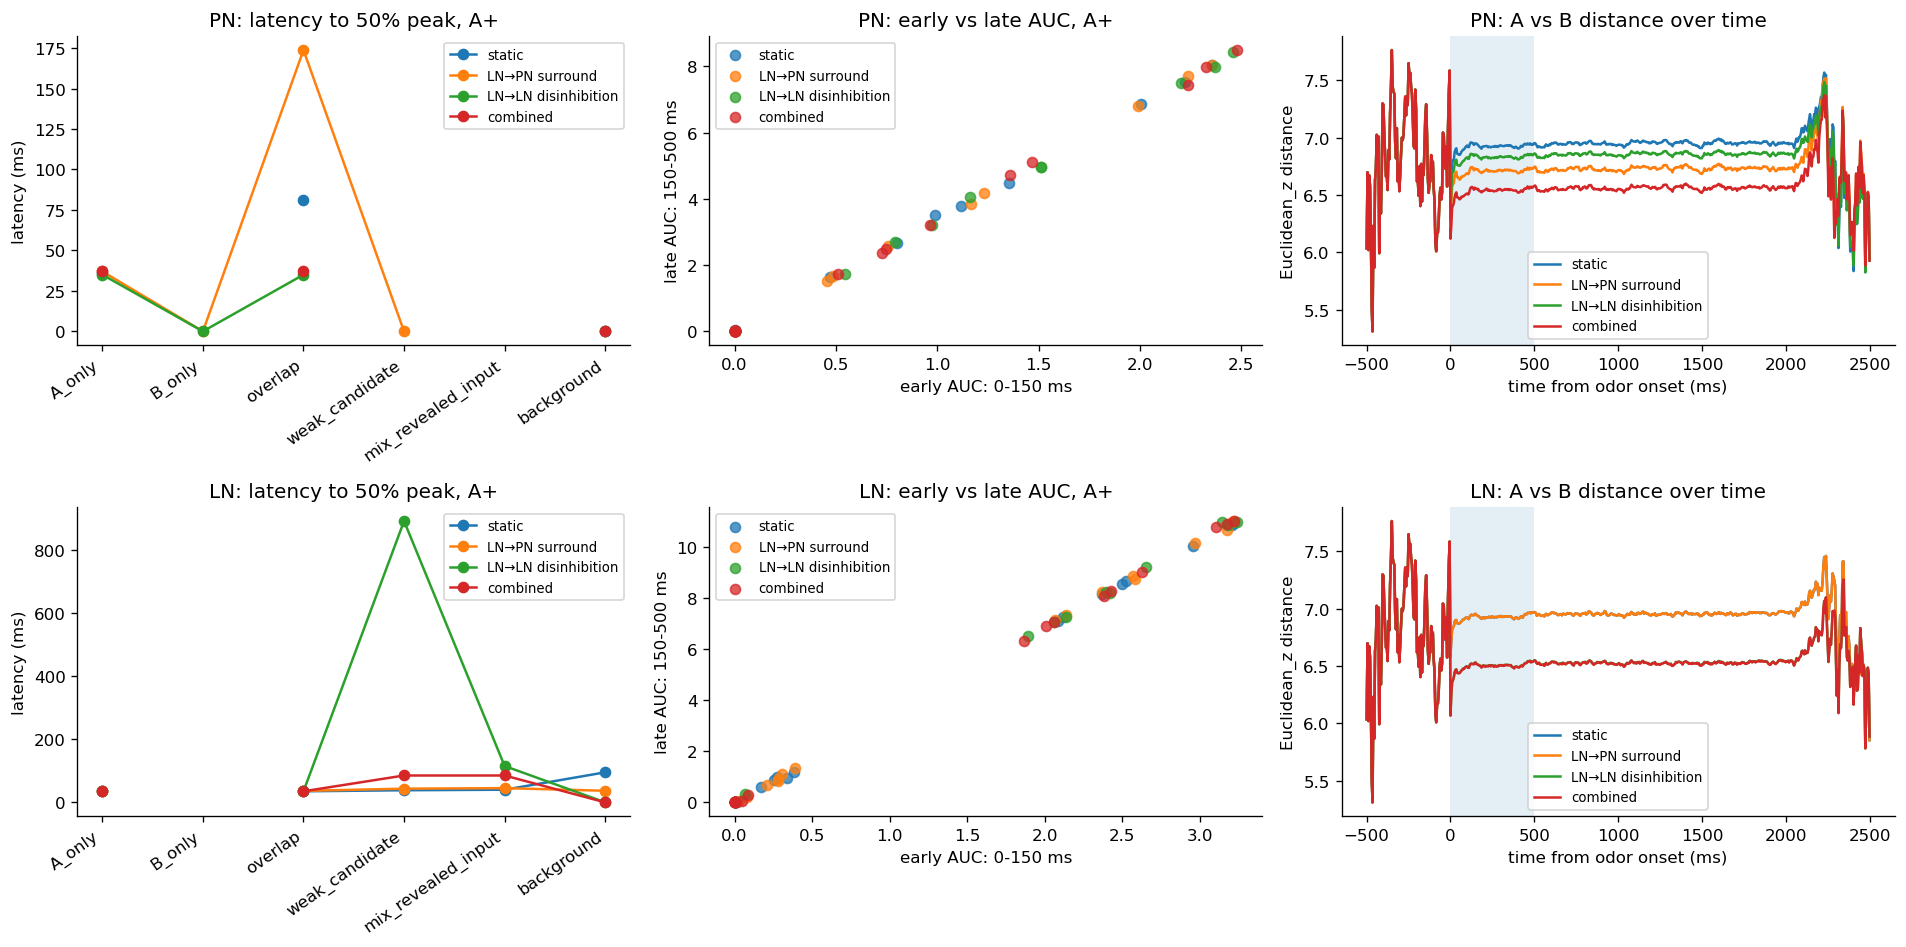

In [17]:
def plot_temporal_dashboard(results, temporal_df):
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))

    for row, pop in enumerate(["PN", "LN"]):
        ax = axes[row, 0]
        sub = temporal_df[(temporal_df["population"] == pop) & (temporal_df["odor"] == "A+")]
        for cond in CONDITIONS:
            vals = []
            for cat in CATEGORY_ORDER:
                s = sub[(sub["condition"] == cond) & (sub["category"] == cat)]["latency50_ms"].dropna()
                vals.append(np.nanmean(s) if len(s) else np.nan)
            ax.plot(range(len(CATEGORY_ORDER)), vals, marker="o", label=cond)
        ax.set_title(f"{pop}: latency to 50% peak, A+")
        ax.set_xticks(range(len(CATEGORY_ORDER)))
        ax.set_xticklabels(CATEGORY_ORDER, rotation=35, ha="right")
        ax.set_ylabel("latency (ms)")
        ax.legend(fontsize=8)

        ax = axes[row, 1]
        for cond in CONDITIONS:
            s = sub[sub["condition"] == cond]
            ax.scatter(s["auc_early"], s["auc_late"], alpha=0.75, label=cond)
        ax.set_title(f"{pop}: early vs late AUC, A+")
        ax.set_xlabel("early AUC: 0-150 ms")
        ax.set_ylabel("late AUC: 150-500 ms")
        ax.legend(fontsize=8)

        ax = axes[row, 2]
        for cond in CONDITIONS:
            res = results[cond]
            A_vec = get_response(res, "A+", pop, "post")
            B_vec = get_response(res, "B", pop, "post")
            t, trace_A = simulate_trace_from_rates(A_vec, P, seed=1000 + res["seed"])
            _, trace_B = simulate_trace_from_rates(B_vec, P, seed=2000 + res["seed"])
            d_t = np.array([distance(trace_A[i], trace_B[i], metric="euclidean_z") for i in range(len(t))])
            ax.plot(t, d_t, label=cond)
        ax.axvspan(0, 500, alpha=0.12)
        ax.set_title(f"{pop}: A vs B distance over time")
        ax.set_xlabel("time from odor onset (ms)")
        ax.set_ylabel("Euclidean_z distance")
        ax.legend(fontsize=8)

    fig.tight_layout()
    savefig(fig, "09_temporal_dashboard")

plot_temporal_dashboard(results, temporal_df)

## 14. Mixture analysis and glomerular circle activation maps

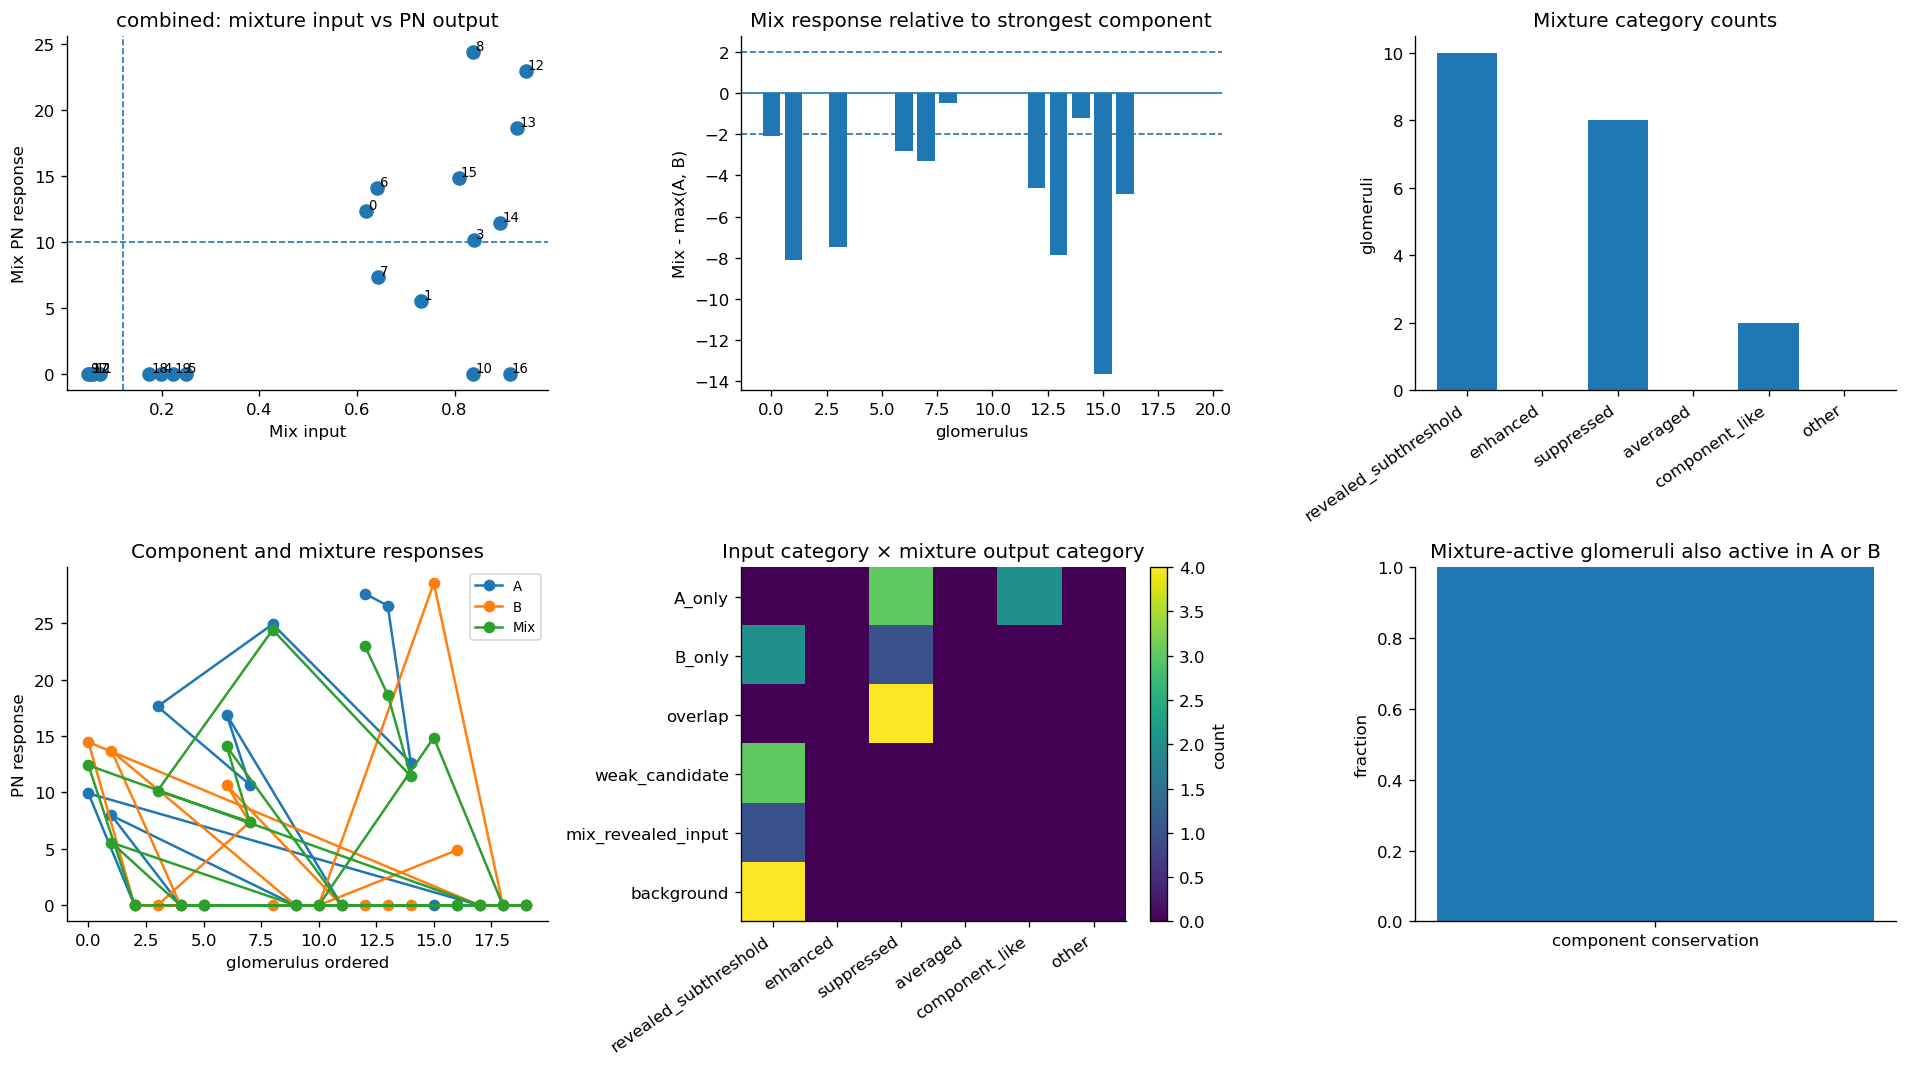

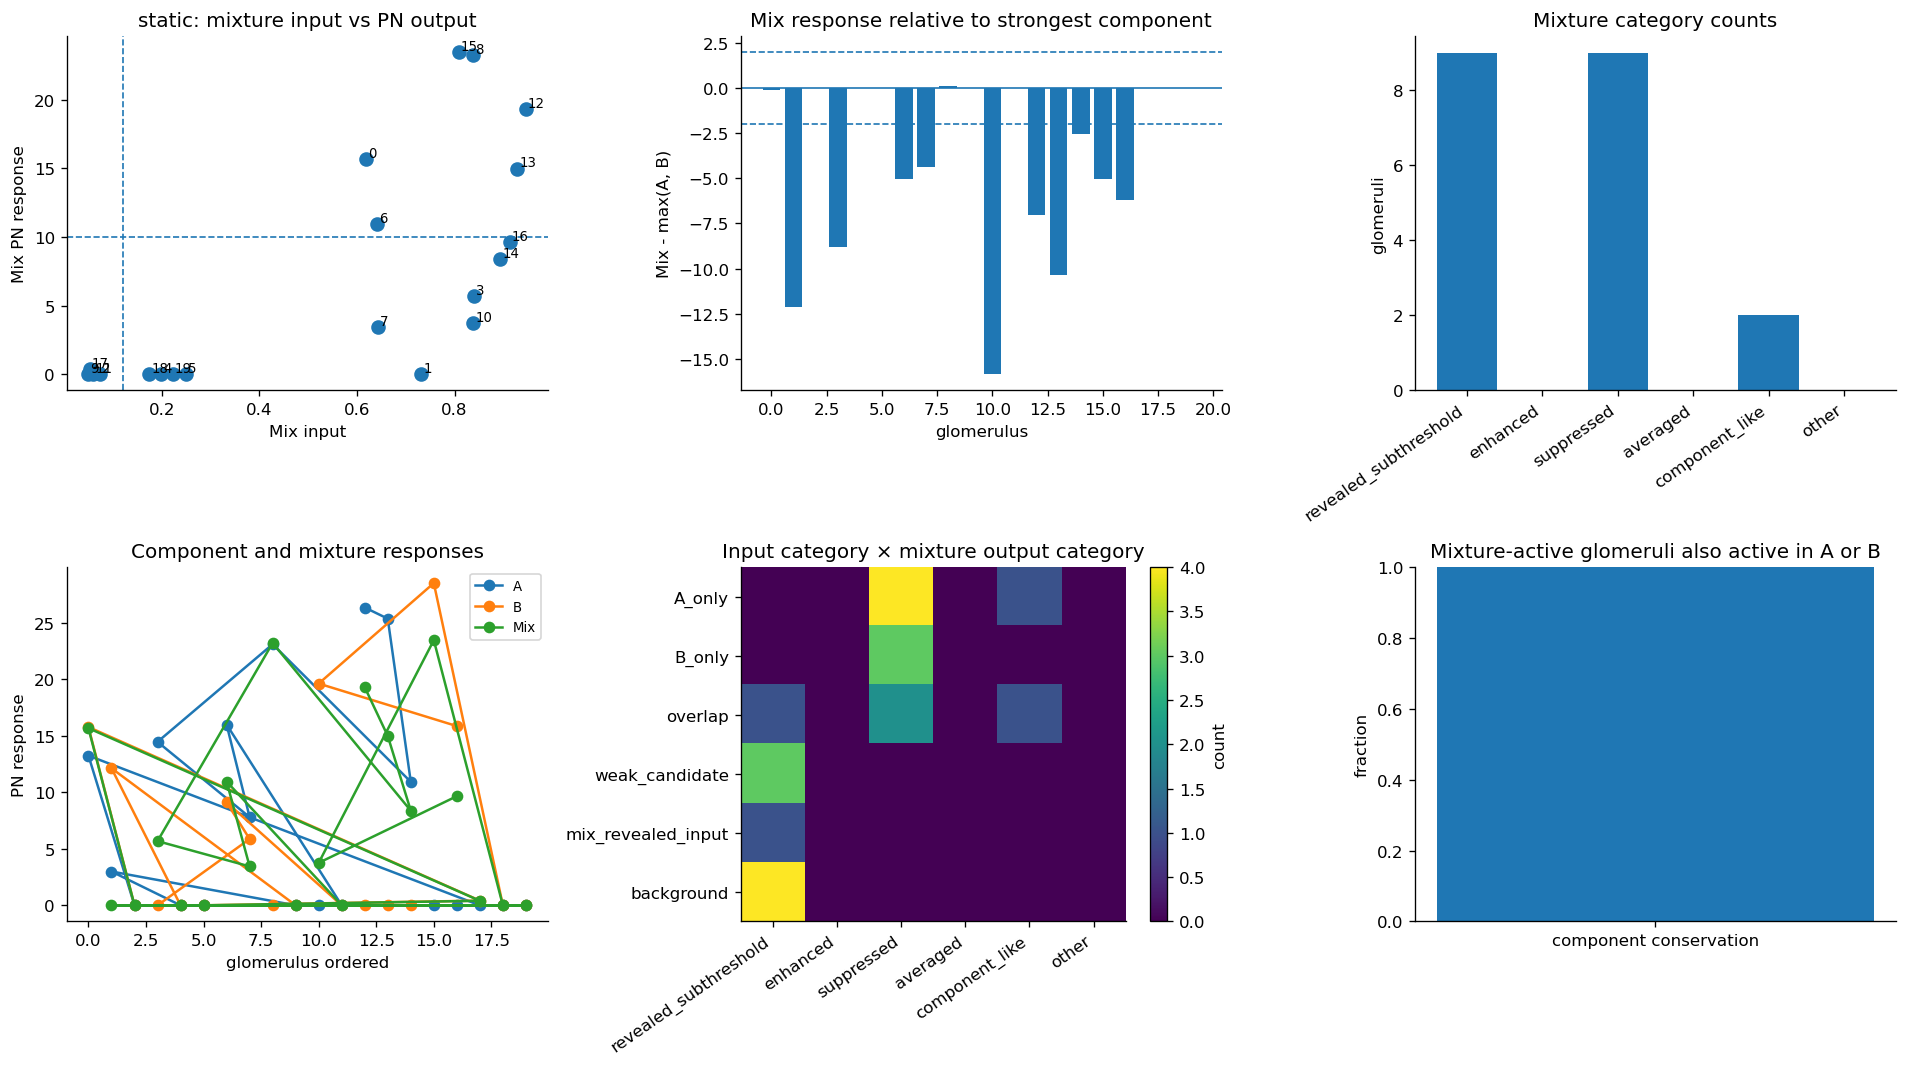

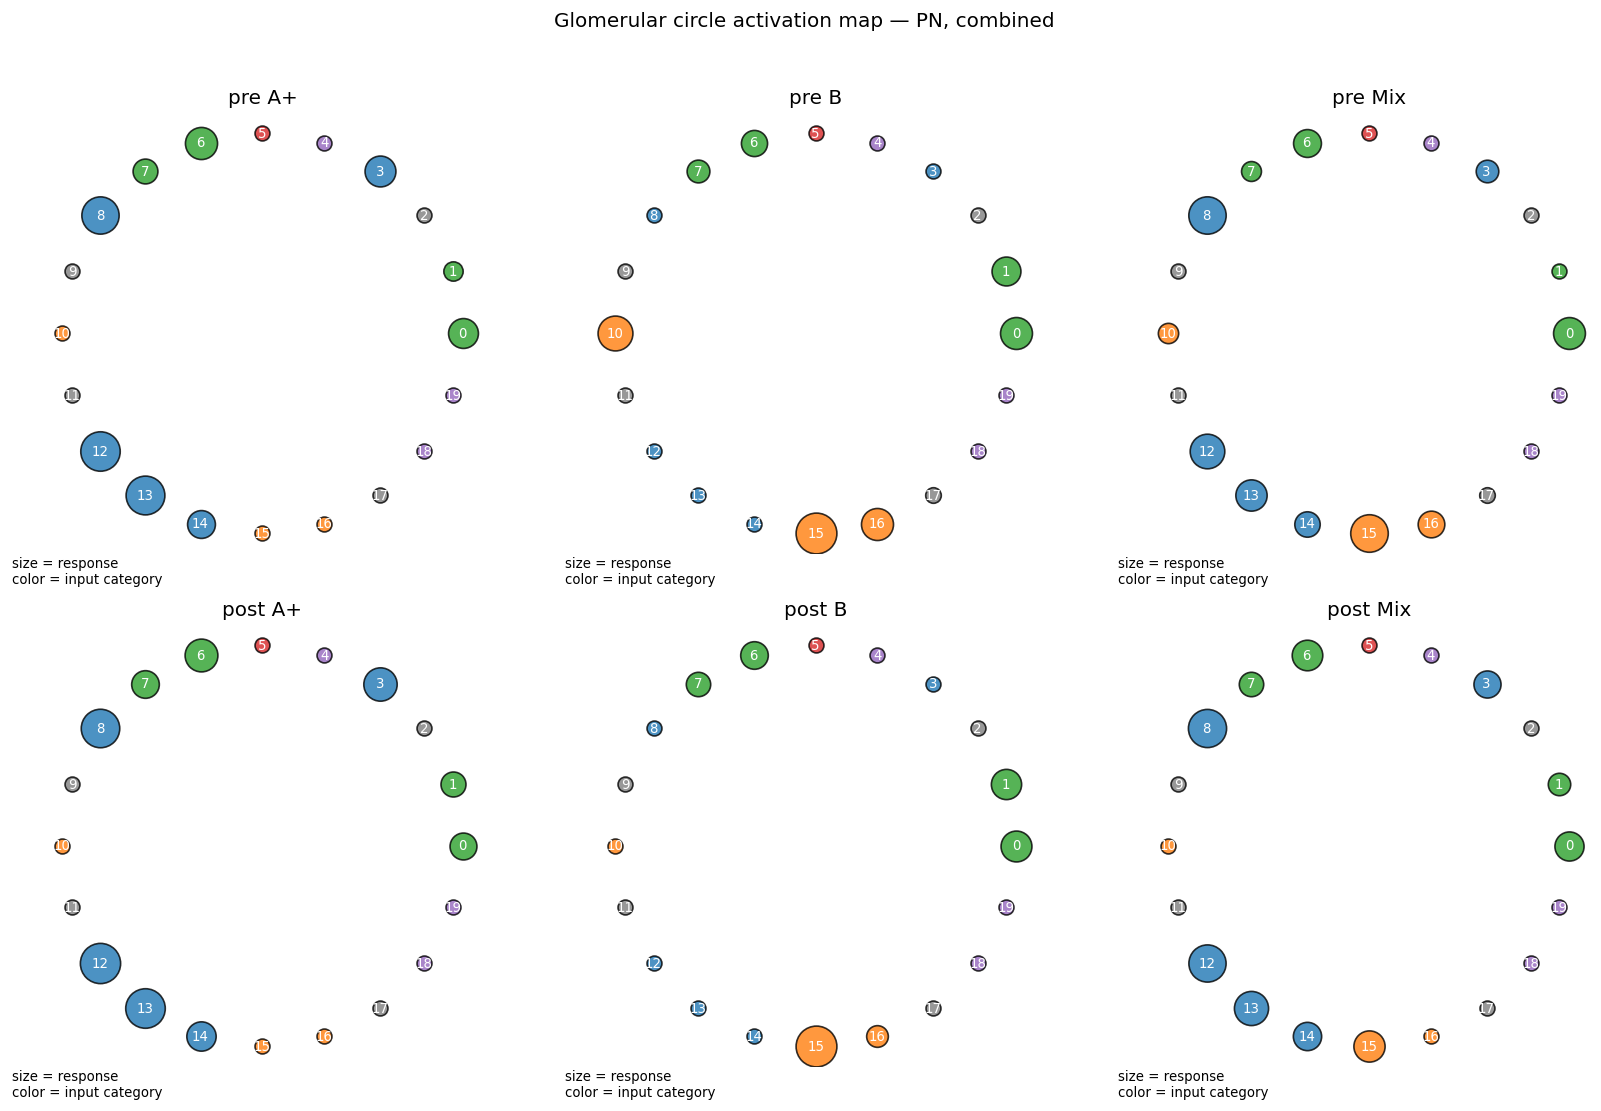

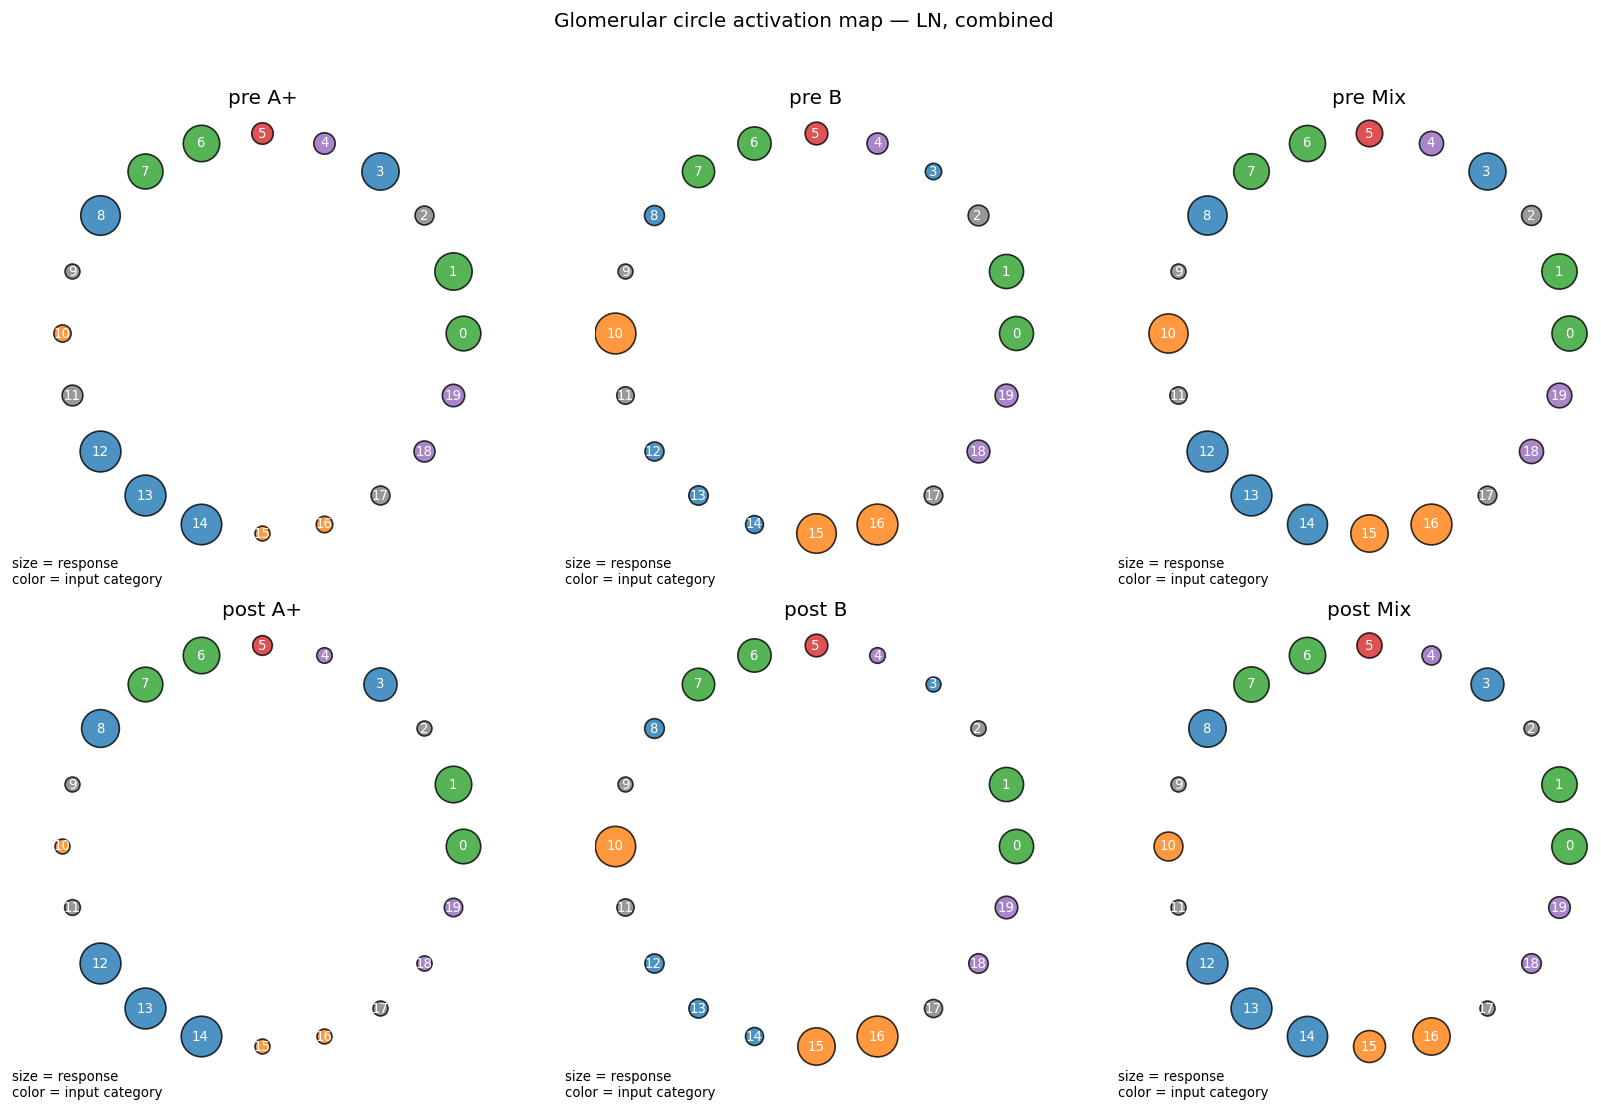

In [18]:
def classify_mixture_glomeruli(result, state="post", population="PN", tol=2.0):
    A = get_response(result, "A+", population, state)
    B = get_response(result, "B", population, state)
    M = get_response(result, "Mix", population, state)

    categories = []
    for g in range(P.n_glom):
        max_comp = max(A[g], B[g])
        if M[g] < P.base_pn + 0.5:
            cat = "revealed_subthreshold"
        elif abs(M[g] - max_comp) <= tol:
            cat = "component_like"
        elif M[g] > max_comp + tol:
            cat = "enhanced"
        elif M[g] < max_comp - tol:
            cat = "suppressed"
        else:
            cat = "averaged"
        categories.append(cat)

    return np.array(categories)

def plot_mixture_dashboard(result, state="post", population="PN"):
    A_in = result["odors"]["A+"]
    B_in = result["odors"]["B"]
    M_in = result["odors"]["Mix"]

    A = get_response(result, "A+", population, state)
    B = get_response(result, "B", population, state)
    M = get_response(result, "Mix", population, state)

    order = order_glomeruli_for_display(result["odors"])
    mix_cat = classify_mixture_glomeruli(result, state=state, population=population)
    counts = pd.Series(mix_cat).value_counts().reindex(
        ["revealed_subthreshold", "enhanced", "suppressed", "averaged", "component_like", "other"],
        fill_value=0,
    )

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))

    ax = axes[0, 0]
    ax.scatter(M_in, M, s=60)
    for g in range(P.n_glom):
        ax.text(M_in[g] + 0.004, M[g] + 0.15, str(g), fontsize=8)
    ax.axvline(P.active_thr, linestyle="--", linewidth=1)
    ax.axhline(10, linestyle="--", linewidth=1)
    ax.set_title(f"{result['condition']}: mixture input vs {population} output")
    ax.set_xlabel("Mix input")
    ax.set_ylabel(f"Mix {population} response")

    ax = axes[0, 1]
    rel = M - np.maximum(A, B)
    ax.bar(np.arange(P.n_glom), rel)
    ax.axhline(0, linewidth=1)
    ax.axhline(2, linestyle="--", linewidth=1)
    ax.axhline(-2, linestyle="--", linewidth=1)
    ax.set_title("Mix response relative to strongest component")
    ax.set_xlabel("glomerulus")
    ax.set_ylabel("Mix - max(A, B)")

    ax = axes[0, 2]
    ax.bar(range(len(counts)), counts.values)
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=35, ha="right")
    ax.set_title("Mixture category counts")
    ax.set_ylabel("glomeruli")

    ax = axes[1, 0]
    ax.plot(order, A[order], marker="o", label="A")
    ax.plot(order, B[order], marker="o", label="B")
    ax.plot(order, M[order], marker="o", label="Mix")
    ax.set_title("Component and mixture responses")
    ax.set_xlabel("glomerulus ordered")
    ax.set_ylabel(f"{population} response")
    ax.legend(fontsize=8)

    ax = axes[1, 1]
    input_cats = result["categories"]
    input_order = CATEGORY_ORDER
    output_order = ["revealed_subthreshold", "enhanced", "suppressed", "averaged", "component_like", "other"]
    table = pd.crosstab(
        pd.Categorical(input_cats, categories=input_order),
        pd.Categorical(mix_cat, categories=output_order),
        dropna=False
    ).reindex(index=input_order, columns=output_order, fill_value=0)
    im = ax.imshow(table.values, aspect="auto")
    ax.set_title("Input category × mixture output category")
    ax.set_xticks(range(len(output_order)))
    ax.set_xticklabels(output_order, rotation=35, ha="right")
    ax.set_yticks(range(len(input_order)))
    ax.set_yticklabels(input_order)
    fig.colorbar(im, ax=ax, label="count")

    ax = axes[1, 2]
    active_mix = M > 10
    active_component = (A > 10) | (B > 10)
    frac = active_component[active_mix].mean() if active_mix.sum() else np.nan
    ax.bar([0], [frac])
    ax.set_ylim(0, 1)
    ax.set_xticks([0])
    ax.set_xticklabels(["component conservation"])
    ax.set_ylabel("fraction")
    ax.set_title("Mixture-active glomeruli also active in A or B")

    fig.tight_layout()
    savefig(fig, f"10_mixture_dashboard_{population}_{result['condition']}")

def plot_glomerular_circle_patterns(result, population="PN"):
    xy = circle_positions(P.n_glom)
    categories = result["categories"]

    fig, axes = plt.subplots(2, 3, figsize=(14, 9))
    states = ["pre", "post"]

    all_rates = []
    for state in states:
        for odor in ODORS:
            all_rates.append(get_response(result, odor, population, state))
    vmax = np.nanmax(all_rates) + 1e-12

    for i, state in enumerate(states):
        for j, odor in enumerate(ODORS):
            ax = axes[i, j]
            vals = get_response(result, odor, population, state)
            ax.set_aspect("equal")
            ax.axis("off")
            ax.set_title(f"{state} {odor}")

            for g in range(P.n_glom):
                size = 80 + 520 * (vals[g] / vmax)
                color = CATEGORY_COLORS.get(categories[g], "tab:gray")
                ax.scatter(xy[g, 0], xy[g, 1], s=size, color=color, alpha=0.8, edgecolor="black")
                ax.text(xy[g, 0], xy[g, 1], str(g), ha="center", va="center", fontsize=8, color="white")

            ax.text(-1.25, -1.25, "size = response\ncolor = input category", fontsize=8)

    fig.suptitle(f"Glomerular circle activation map — {population}, {result['condition']}", y=1.02)
    fig.tight_layout()
    savefig(fig, f"11_glomerular_circle_{population}_{result['condition']}")

plot_mixture_dashboard(results["combined"], population="PN")
plot_mixture_dashboard(results["static"], population="PN")
plot_glomerular_circle_patterns(results["combined"], population="PN")
plot_glomerular_circle_patterns(results["combined"], population="LN")

## 15. Causal disinhibition diagnostic

In [19]:
def causal_disinhibition_df(results):
    rows = []
    for cond, res in results.items():
        A = res["odors"]["A+"]
        A_mask = A > P.active_thr

        if len(res["diag_history"]):
            competitor_factor = res["diag_history"][-1]["competitor_factor"]
        else:
            competitor_factor = np.zeros(P.n_glom)

        competitor_mask = competitor_factor >= np.nanquantile(competitor_factor, 0.70)

        for state_i in range(P.n_trials + 1):
            Wlp = res["W_LNPN_history"][state_i]
            Wll = res["W_LNLN_history"][state_i]
            tests = evaluate_odors(res["odors"], Wlp, Wll, P)

            PN_mix = tests["Mix"]["PN"]
            LN_mix = tests["Mix"]["LN"]

            if competitor_mask.sum() and A_mask.sum():
                competitor_to_A_proxy = float((LN_mix[competitor_mask] @ Wlp[competitor_mask][:, A_mask]).mean())
            else:
                competitor_to_A_proxy = np.nan

            rows.append({
                "condition": cond,
                "weight_state": state_i,
                "competitor_LN_activity_during_Mix": float(np.nanmean(LN_mix[competitor_mask])) if competitor_mask.sum() else np.nan,
                "competitor_to_A_inhibition_proxy": competitor_to_A_proxy,
                "A_PN_activity_during_Mix": float(np.nanmean(PN_mix[A_mask])) if A_mask.sum() else np.nan,
            })

    df = pd.DataFrame(rows)
    save_table(df, "causal_disinhibition_diagnostic")
    return df

causal_df = causal_disinhibition_df(results)
display(causal_df.head())

,condition,weight_state,competitor_LN_activity_during_Mix,competitor_to_A_inhibition_proxy,A_PN_activity_during_Mix
0,static,0,17.346264,4.003105,9.240183
1,static,1,17.346264,4.003105,9.240183
2,static,2,17.346264,4.003105,9.240183
3,static,3,17.346264,4.003105,9.240183
4,static,4,17.346264,4.003105,9.240183


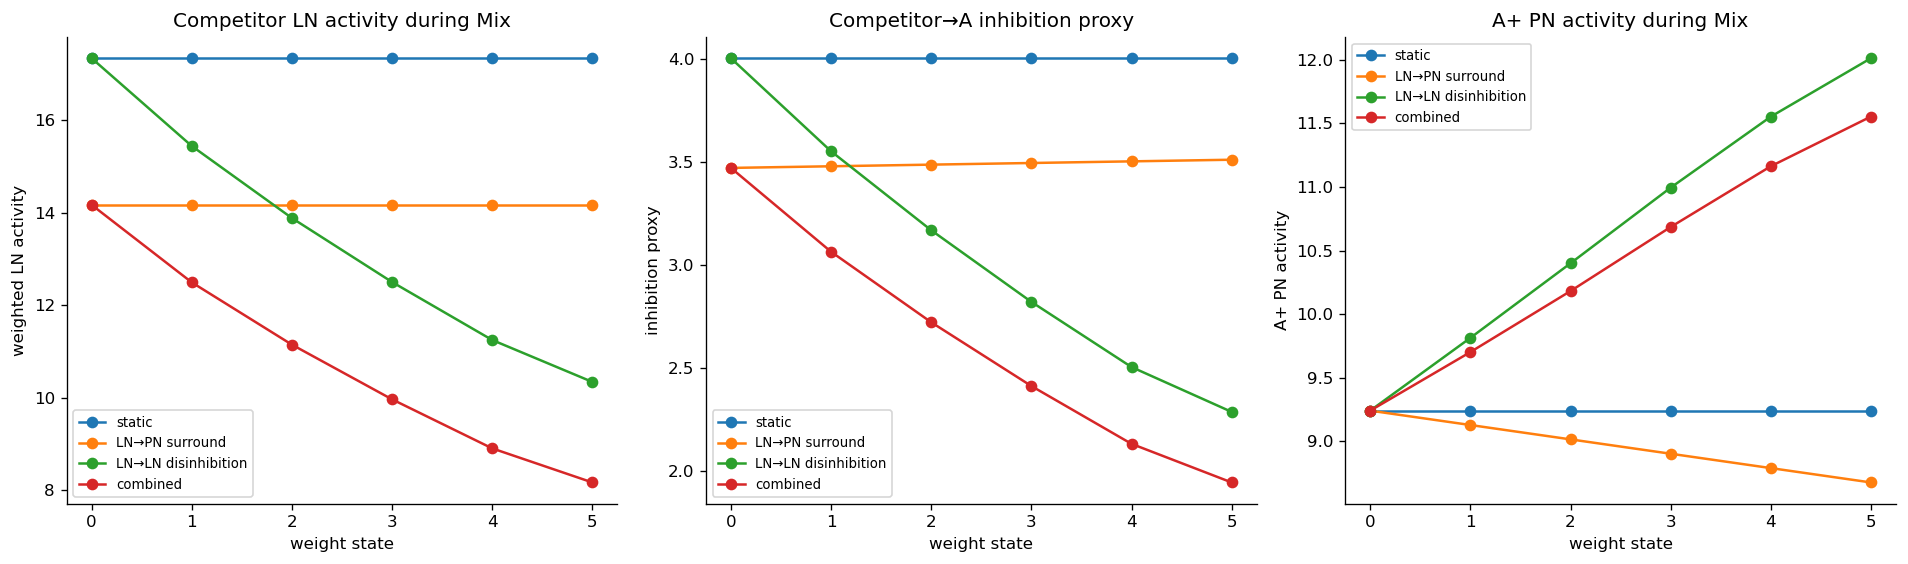

In [20]:
def plot_causal_disinhibition(causal_df):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

    ycols = [
        ("competitor_LN_activity_during_Mix", "Competitor LN activity during Mix", "weighted LN activity"),
        ("competitor_to_A_inhibition_proxy", "Competitor→A inhibition proxy", "inhibition proxy"),
        ("A_PN_activity_during_Mix", "A+ PN activity during Mix", "A+ PN activity"),
    ]

    for ax, (col, title, ylabel) in zip(axes, ycols):
        for cond in CONDITIONS:
            sub = causal_df[causal_df["condition"] == cond]
            ax.plot(sub["weight_state"], sub[col], marker="o", label=cond)
        ax.set_title(title)
        ax.set_xlabel("weight state")
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=8)

    fig.tight_layout()
    savefig(fig, "12_causal_disinhibition")

plot_causal_disinhibition(causal_df)

## 16. Robustness across random seeds

This is the most important control for avoiding a "lucky network" argument.

Default: `N_SEEDS = 20`. Increase to 100 or 200 when you want publication-quality robustness.

In [21]:
def run_many_seeds(n_seeds=50, p=P):
    metric_rows = []
    summary_rows = []

    for seed in range(n_seeds):
        seed_results = run_all_conditions(seed=seed, p=p)

        for cond, res in seed_results.items():
            for state in ["pre", "post"]:
                for pop in POPULATIONS:
                    metric_rows.extend(collect_distance_metrics(res, state=state, population=pop))

            bias_pre = mix_a_bias(res, population="PN", state="pre", metric="euclidean_z")
            bias_post = mix_a_bias(res, population="PN", state="post", metric="euclidean_z")

            A = get_response(res, "A+", "PN", "post")
            B = get_response(res, "B", "PN", "post")
            M = get_response(res, "Mix", "PN", "post")

            dA = distance(M, A, "euclidean_z")
            dB = distance(M, B, "euclidean_z")
            readout_A = float(dA < dB)
            sparsity_mix = float(np.mean(M > 10.0))

            summary_rows.append({
                "seed": seed,
                "condition": cond,
                "A_bias_pre": bias_pre,
                "A_bias_post": bias_post,
                "delta_A_bias": bias_post - bias_pre,
                "readout_A_for_Mix_post": readout_A,
                "sparsity_Mix_post": sparsity_mix,
                "d_A_Mix_post": dA,
                "d_B_Mix_post": dB,
            })

    metrics_df = pd.DataFrame(metric_rows)
    summary_df = pd.DataFrame(summary_rows)

    save_table(metrics_df, "many_seed_distance_metrics")
    save_table(summary_df, "many_seed_summary_metrics")

    return metrics_df, summary_df

N_SEEDS = 20
many_distance_df, many_summary_df = run_many_seeds(n_seeds=N_SEEDS, p=P)

print(f"Finished robustness analysis with {N_SEEDS} seeds.")
display(many_summary_df.head())

Finished robustness analysis with 20 seeds.


,seed,condition,A_bias_pre,A_bias_post,delta_A_bias,readout_A_for_Mix_post,sparsity_Mix_post,d_A_Mix_post,d_B_Mix_post
0,0,static,1.573146,1.573146,0.000000,1.0,0.30,2.878846,4.451992
1,0,LN→PN surround,1.573146,2.734536,1.161390,1.0,0.25,1.735651,4.470187
2,0,LN→LN disinhibition,1.573146,1.740290,0.167144,1.0,0.35,2.673656,4.413946
3,0,combined,1.573146,3.259791,1.686645,1.0,0.30,1.217763,4.477554
4,1,static,0.444401,0.444401,0.000000,1.0,0.40,3.887457,4.331857


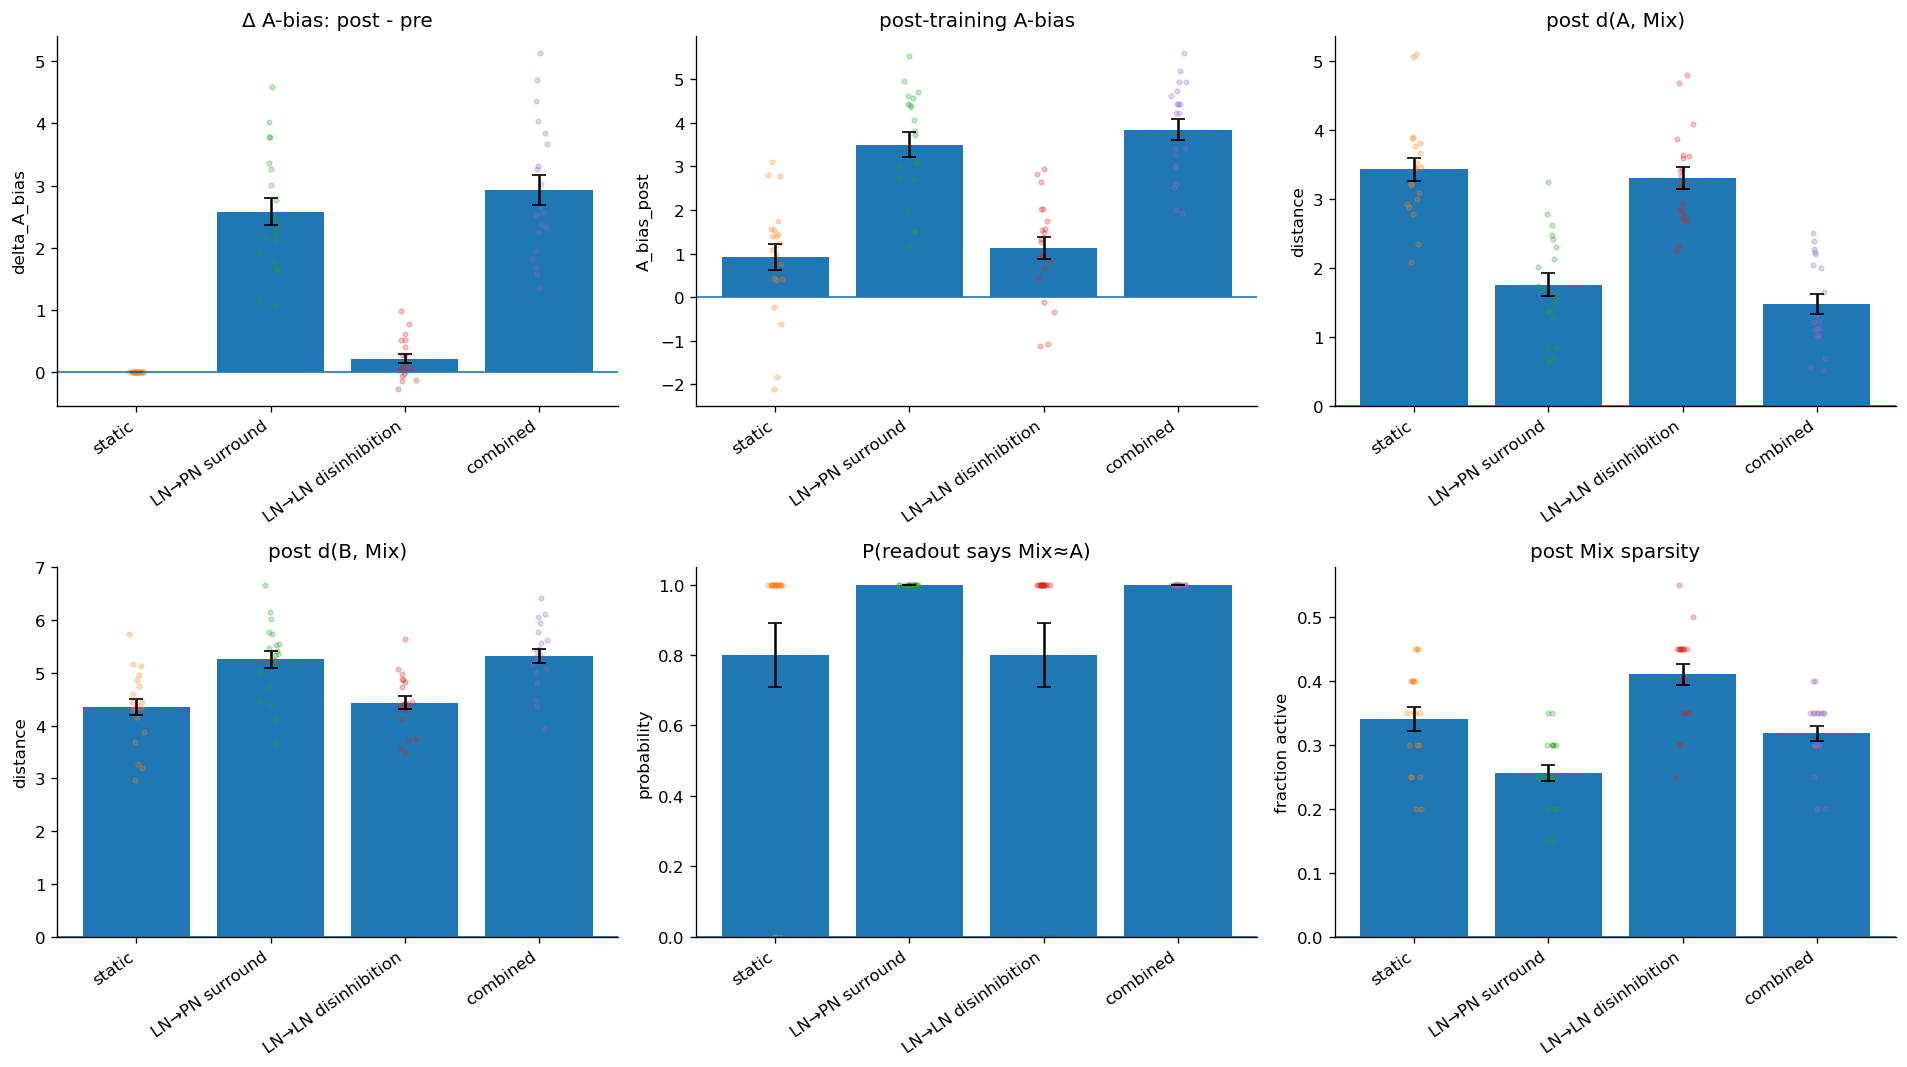

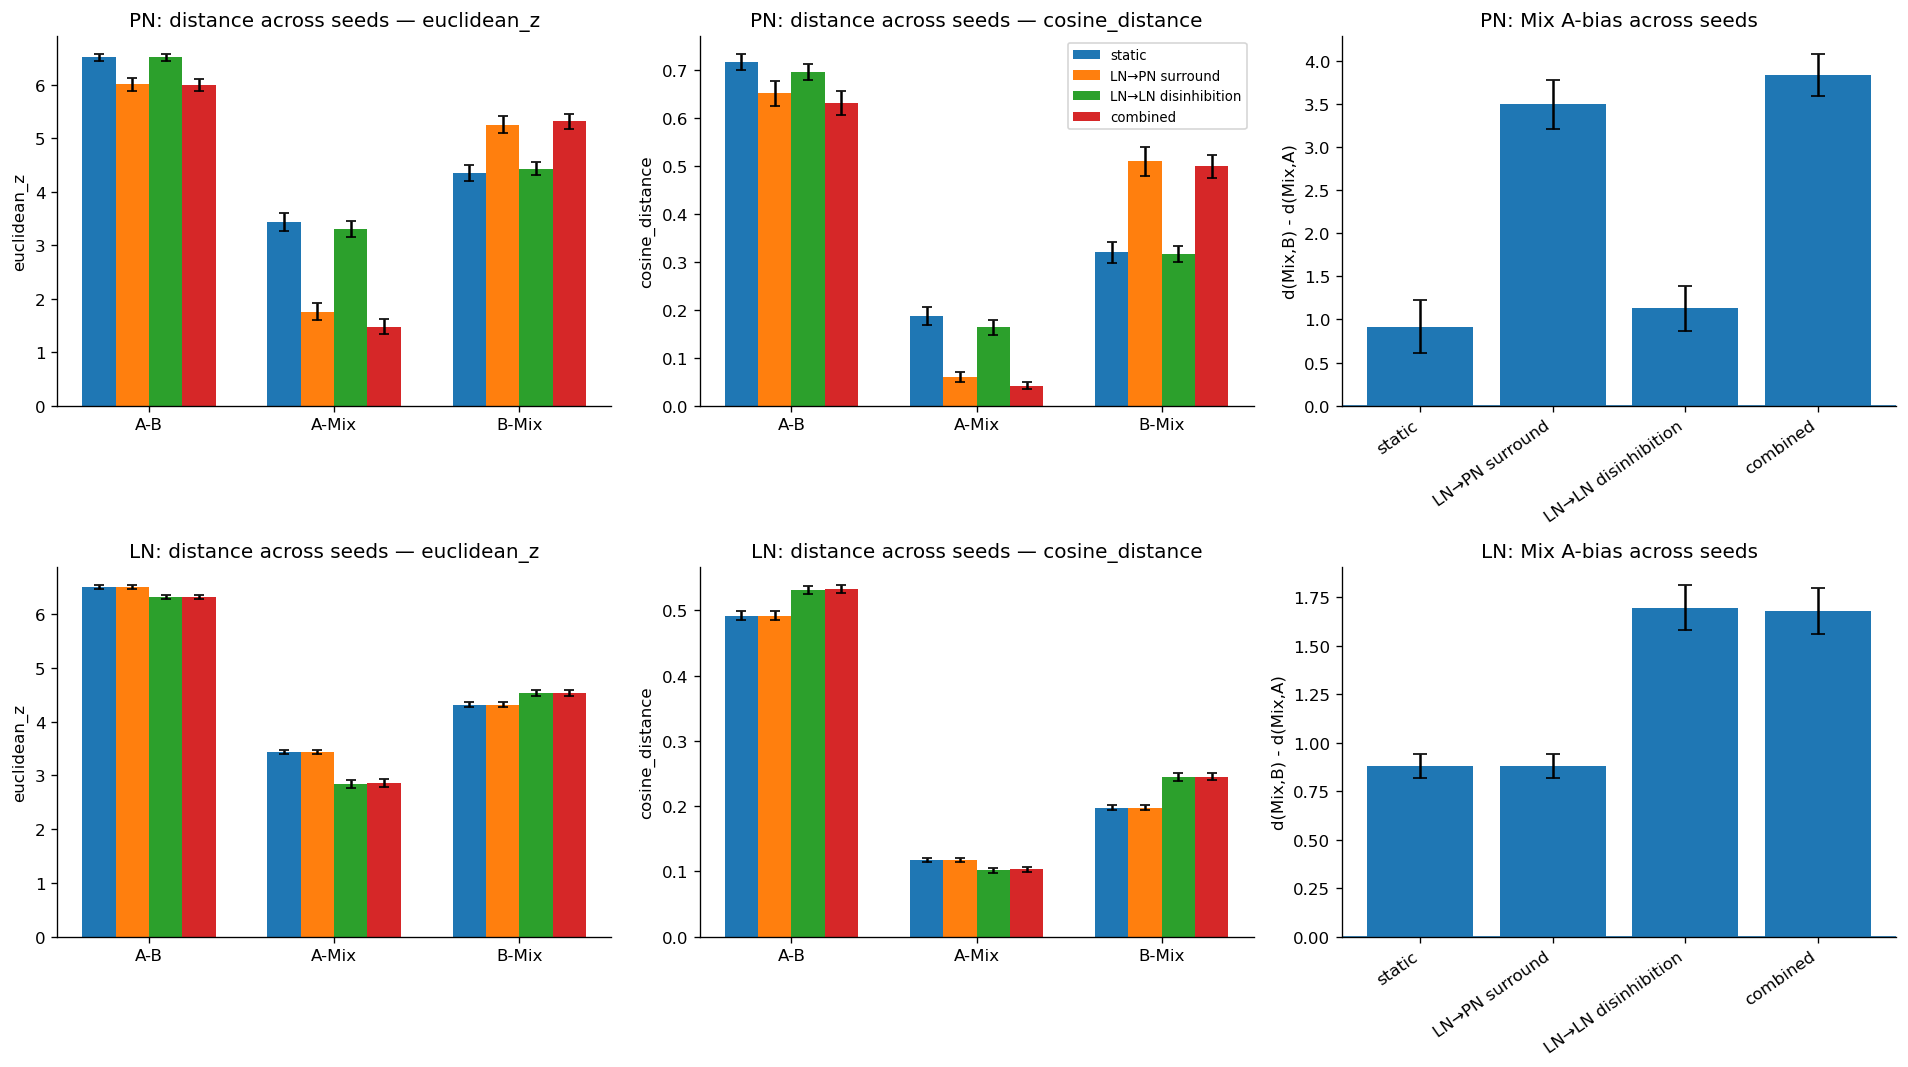

In [22]:
def sem(x):
    x = pd.Series(x).dropna()
    if len(x) <= 1:
        return np.nan
    return x.std(ddof=1) / np.sqrt(len(x))

def _scatter_by_condition(ax, summary_df, col):
    """Small jittered dots on barplots."""
    rng = np.random.default_rng(123)
    for i, cond in enumerate(CONDITIONS):
        vals = summary_df.loc[summary_df["condition"] == cond, col].dropna().values
        if len(vals):
            jitter = rng.normal(0, 0.035, len(vals))
            ax.scatter(np.full(len(vals), i) + jitter, vals, s=8, alpha=0.25)

def plot_seed_robustness(summary_df):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))

    metrics = [
        ("delta_A_bias", "Δ A-bias: post - pre", "delta_A_bias"),
        ("A_bias_post", "post-training A-bias", "A_bias_post"),
        ("d_A_Mix_post", "post d(A, Mix)", "distance"),
        ("d_B_Mix_post", "post d(B, Mix)", "distance"),
        ("readout_A_for_Mix_post", "P(readout says Mix≈A)", "probability"),
        ("sparsity_Mix_post", "post Mix sparsity", "fraction active"),
    ]

    for ax, (col, title, ylabel) in zip(axes.flat, metrics):
        grouped = summary_df.groupby("condition")[col].agg(["mean", sem]).reindex(CONDITIONS)
        x = np.arange(len(CONDITIONS))
        ax.bar(x, grouped["mean"].values, yerr=grouped["sem"].values, capsize=4)
        _scatter_by_condition(ax, summary_df, col)
        ax.axhline(0, linewidth=1)
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.set_xticks(x)
        ax.set_xticklabels(CONDITIONS, rotation=35, ha="right")

    fig.tight_layout()
    savefig(fig, "13_many_seed_robustness")

def plot_many_seed_distance_dashboard(many_distance_df):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    pairs = ["A-B", "A-Mix", "B-Mix"]

    for row, pop in enumerate(["PN", "LN"]):
        for col, metric in enumerate(["euclidean_z", "cosine_distance"]):
            ax = axes[row, col]
            sub = many_distance_df[
                (many_distance_df["state"] == "post")
                & (many_distance_df["population"] == pop)
                & (many_distance_df["metric"] == metric)
                & (many_distance_df["pair"].isin(pairs))
            ]

            grouped = (
                sub.groupby(["condition", "pair"])["value"]
                .agg(["mean", sem])
                .reset_index()
            )

            x = np.arange(len(pairs))
            width = 0.18
            for i, cond in enumerate(CONDITIONS):
                vals = []
                errs = []
                for pair in pairs:
                    row_sel = grouped[(grouped["condition"] == cond) & (grouped["pair"] == pair)]
                    vals.append(row_sel["mean"].iloc[0] if len(row_sel) else np.nan)
                    errs.append(row_sel["sem"].iloc[0] if len(row_sel) else np.nan)
                ax.bar(x + (i - 1.5) * width, vals, width=width, yerr=errs, capsize=3, label=cond)

            ax.set_title(f"{pop}: distance across seeds — {metric}")
            ax.set_xticks(x)
            ax.set_xticklabels(pairs)
            ax.set_ylabel(metric)
            if row == 0 and col == 1:
                ax.legend(fontsize=8)

        ax = axes[row, 2]
        sub = many_distance_df[
            (many_distance_df["state"] == "post")
            & (many_distance_df["population"] == pop)
            & (many_distance_df["metric"] == "euclidean_z")
            & (many_distance_df["pair"] == "Mix A-bias")
        ]
        grouped = sub.groupby("condition")["value"].agg(["mean", sem]).reindex(CONDITIONS)
        x = np.arange(len(CONDITIONS))
        ax.bar(x, grouped["mean"], yerr=grouped["sem"], capsize=4)
        ax.axhline(0, linewidth=1)
        ax.set_title(f"{pop}: Mix A-bias across seeds")
        ax.set_ylabel("d(Mix,B) - d(Mix,A)")
        ax.set_xticks(x)
        ax.set_xticklabels(CONDITIONS, rotation=35, ha="right")

    fig.tight_layout()
    savefig(fig, "14_many_seed_distance_dashboard")

plot_seed_robustness(many_summary_df)
plot_many_seed_distance_dashboard(many_distance_df)

## 17. PCA / representational geometry

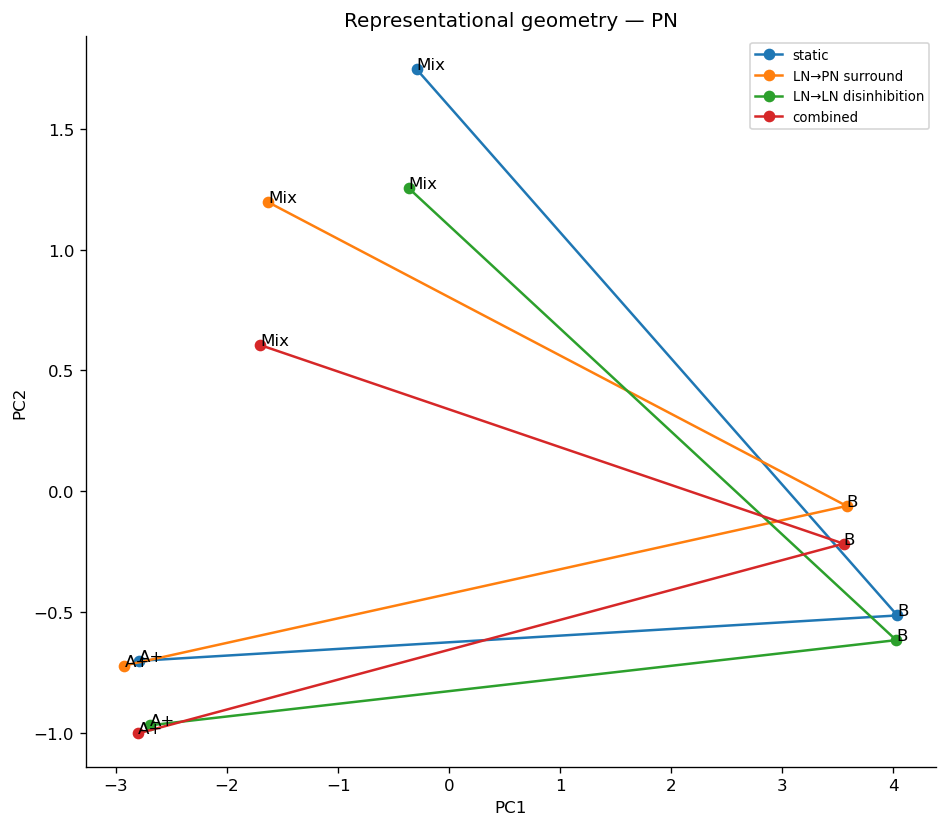

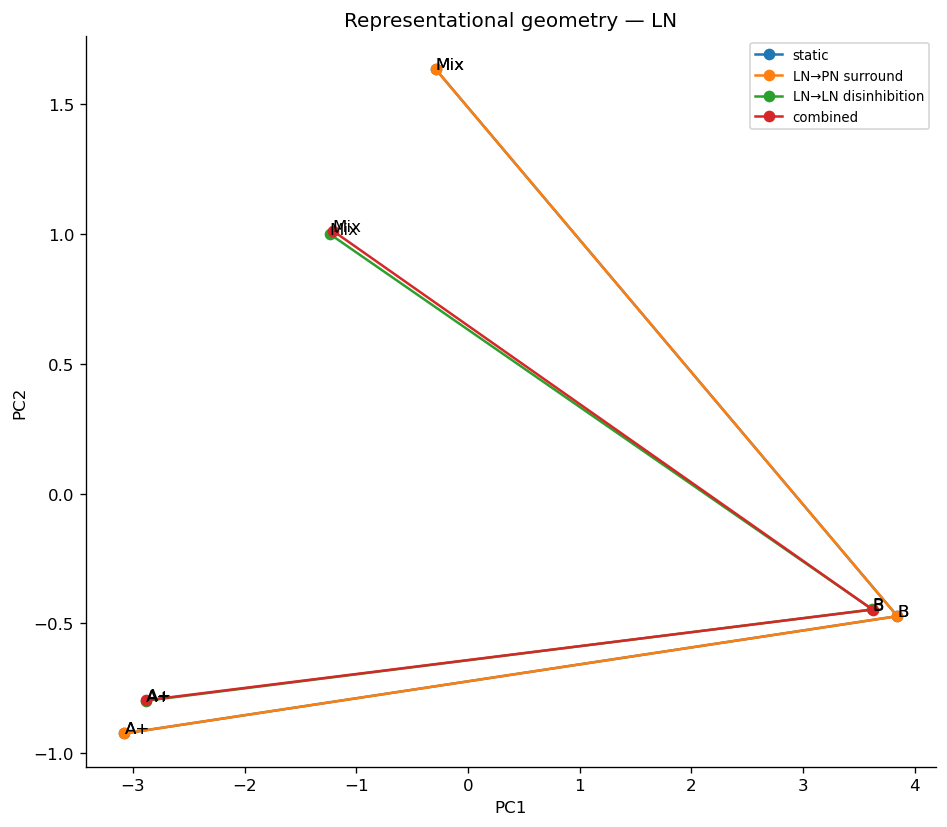

In [23]:
def pca_geometry(results, population="PN", state="post"):
    if not SKLEARN_AVAILABLE:
        print("scikit-learn is not available. Install with: pip install scikit-learn")
        return

    rows = []
    labels = []
    for cond in CONDITIONS:
        res = results[cond]
        for odor in ODORS:
            rows.append(zscore_vector(get_response(res, odor, population, state)))
            labels.append((cond, odor))

    X = np.vstack(rows)
    pca = PCA(n_components=2)
    XY = pca.fit_transform(X)

    fig, ax = plt.subplots(figsize=(8, 7))

    for cond in CONDITIONS:
        idxs = [i for i, (c, o) in enumerate(labels) if c == cond]
        pts = XY[idxs]
        ax.plot(pts[:, 0], pts[:, 1], marker="o", label=cond)
        for (x, y), (_, odor) in zip(pts, [labels[i] for i in idxs]):
            ax.text(x, y, odor, fontsize=10)

    ax.set_title(f"Representational geometry — {population}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(fontsize=8)
    fig.tight_layout()
    savefig(fig, f"15_pca_geometry_{population}")

pca_geometry(results, population="PN", state="post")
pca_geometry(results, population="LN", state="post")

## 18. Automatic text summary

In [24]:
def print_interpretive_summary(summary_df):
    s = summary_df.groupby("condition").agg({
        "delta_A_bias": ["mean", sem],
        "A_bias_post": ["mean", sem],
        "readout_A_for_Mix_post": ["mean", sem],
        "d_A_Mix_post": ["mean", sem],
        "d_B_Mix_post": ["mean", sem],
    }).reindex(CONDITIONS)

    print("Core interpretation:")
    print("--------------------")
    for cond in CONDITIONS:
        delta = s.loc[cond, ("delta_A_bias", "mean")]
        delta_sem = s.loc[cond, ("delta_A_bias", "sem")]
        post = s.loc[cond, ("A_bias_post", "mean")]
        pA = s.loc[cond, ("readout_A_for_Mix_post", "mean")]
        print(f"{cond:22s} | ΔA-bias = {delta: .3f} ± {delta_sem: .3f} | post A-bias = {post: .3f} | P(Mix≈A) = {pA: .2f}")

    best = s[("delta_A_bias", "mean")].idxmax()
    print("\nMost effective condition by ΔA-bias:", best)

    if best == "combined":
        print("Good: combined LN→PN + LN→LN gives the strongest mixture shift toward A.")
    else:
        print("Check tuning: combined is not the strongest condition in this seed set.")

print_interpretive_summary(many_summary_df)

Core interpretation:
--------------------
static                 | ΔA-bias =  0.000 ±  0.000 | post A-bias =  0.917 | P(Mix≈A) =  0.80
LN→PN surround         | ΔA-bias =  2.579 ±  0.218 | post A-bias =  3.495 | P(Mix≈A) =  1.00
LN→LN disinhibition    | ΔA-bias =  0.211 ±  0.074 | post A-bias =  1.128 | P(Mix≈A) =  0.80
combined               | ΔA-bias =  2.925 ±  0.243 | post A-bias =  3.841 | P(Mix≈A) =  1.00

Most effective condition by ΔA-bias: combined
Good: combined LN→PN + LN→LN gives the strongest mixture shift toward A.


## 19. Optional Brian2 spiking sanity-check

This section is **off by default**. It converts trained weights from the rate model into a minimal spiking network and checks whether the trained connectivity produces compatible PN firing patterns.

Set `RUN_BRIAN2 = True` only if Brian2 is installed in the active environment.

In [25]:
RUN_BRIAN2 = False

if RUN_BRIAN2:
    import brian2 as b2

    def brian2_single_odor_response(
        odor_drive,
        W_lnpn,
        W_lnln,
        sim_ms=2500,
        odor_on_ms=500,
        odor_off_ms=2000,
        seed=0,
    ):
        """
        Minimal Brian2 AL sanity check:
        ORN Poisson input -> PN and LN LIF units.
        LN→PN and LN→LN are inhibitory, using trained rate-model weights.
        """
        b2.start_scope()
        np.random.seed(seed)
        b2.seed(seed)

        n = P.n_glom
        dt = 1 * b2.ms
        b2.defaultclock.dt = dt

        times = np.arange(0, sim_ms + 1, 1)
        rates = np.ones((len(times), n)) * 5.0
        on = (times >= odor_on_ms) & (times <= odor_off_ms)
        rates[on] = 5.0 + 120.0 * odor_drive[None, :]
        rate_timed = b2.TimedArray(rates * b2.Hz, dt=1*b2.ms)

        ORN = b2.PoissonGroup(n, rates="rate_timed(t, i)")

        eqs = """
        dv/dt = (v_rest - v + ge*(E_exc-v) + gi*(E_inh-v)) / tau_m : volt
        dge/dt = -ge / tau_e : 1
        dgi/dt = -gi / tau_i : 1
        """
        v_rest = -65 * b2.mV
        v_reset = -70 * b2.mV
        v_th = -50 * b2.mV
        E_exc = 0 * b2.mV
        E_inh = -80 * b2.mV
        tau_m = 20 * b2.ms
        tau_e = 5 * b2.ms
        tau_i = 10 * b2.ms

        PN = b2.NeuronGroup(
            n, eqs,
            threshold="v > v_th",
            reset="v = v_reset",
            refractory=3*b2.ms,
            method="euler",
            namespace=dict(v_rest=v_rest, E_exc=E_exc, E_inh=E_inh,
                           tau_m=tau_m, tau_e=tau_e, tau_i=tau_i,
                           v_th=v_th, v_reset=v_reset),
        )
        LN = b2.NeuronGroup(
            n, eqs,
            threshold="v > v_th",
            reset="v = v_reset",
            refractory=3*b2.ms,
            method="euler",
            namespace=dict(v_rest=v_rest, E_exc=E_exc, E_inh=E_inh,
                           tau_m=tau_m, tau_e=tau_e, tau_i=tau_i,
                           v_th=v_th, v_reset=v_reset),
        )
        PN.v = v_rest
        LN.v = v_rest

        S_op = b2.Synapses(ORN, PN, on_pre="ge_post += 0.10")
        S_ol = b2.Synapses(ORN, LN, on_pre="ge_post += 0.12")
        S_op.connect(j="i")
        S_ol.connect(j="i")

        pre_lp, post_lp = np.nonzero(W_lnpn > 0)
        S_lp = b2.Synapses(LN, PN, "w : 1", on_pre="gi_post += w")
        S_lp.connect(i=pre_lp, j=post_lp)
        S_lp.w = W_lnpn[pre_lp, post_lp] * 0.18

        pre_ll, post_ll = np.nonzero(W_lnln > 0)
        S_ll = b2.Synapses(LN, LN, "w : 1", on_pre="gi_post += w")
        S_ll.connect(i=pre_ll, j=post_ll)
        S_ll.w = W_lnln[pre_ll, post_ll] * 0.14

        sp_pn = b2.SpikeMonitor(PN)
        sp_ln = b2.SpikeMonitor(LN)

        b2.run(sim_ms * b2.ms)

        pn_rates = np.zeros(n)
        ln_rates = np.zeros(n)
        win_s = (odor_off_ms - odor_on_ms) / 1000

        for g in range(n):
            pn_rates[g] = np.sum((sp_pn.i == g) & (sp_pn.t/b2.ms >= odor_on_ms) & (sp_pn.t/b2.ms <= odor_off_ms)) / win_s
            ln_rates[g] = np.sum((sp_ln.i == g) & (sp_ln.t/b2.ms >= odor_on_ms) & (sp_ln.t/b2.ms <= odor_off_ms)) / win_s

        return pn_rates, ln_rates, sp_pn, sp_ln

    res = results["combined"]
    WlpF = res["W_LNPN_history"][-1]
    WllF = res["W_LNLN_history"][-1]
    pn_spk, ln_spk, sp_pn, sp_ln = brian2_single_odor_response(res["odors"]["Mix"], WlpF, WllF, seed=SEED)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(np.arange(P.n_glom), pn_spk)
    ax.set_title("Brian2 sanity-check: PN rates during Mix")
    ax.set_xlabel("glomerulus")
    ax.set_ylabel("spikes/s")
    fig.tight_layout()
    savefig(fig, "16_brian2_mix_pn_sanity_check")
else:
    print("Brian2 section skipped. Set RUN_BRIAN2 = True to run it.")

Brian2 section skipped. Set RUN_BRIAN2 = True to run it.


## 20. Output manifest

In [26]:
files = sorted(OUTPUT_DIR.glob("*"))
print(f"{len(files)} files in {OUTPUT_DIR.resolve()}:")
for f in files[:80]:
    print(" -", f.name)
if len(files) > 80:
    print(f"... and {len(files) - 80} more files")

26 files in C:\Users\agust\OneDrive\Desktop notebook casa\results_AL_local_plasticity:
 - 01_input_dashboard.png
 - 02_circuit_schematic.png
 - 03_connectivity_circle_combined.png
 - 04_weight_dashboard_combined.png
 - 05_plasticity_rule_dashboard_combined.png
 - 06_training_summary.png
 - 07_test_dashboard_LN.png
 - 07_test_dashboard_PN.png
 - 08_distance_dashboard.png
 - 09_temporal_dashboard.png
 - 10_mixture_dashboard_PN_combined.png
 - 10_mixture_dashboard_PN_static.png
 - 11_glomerular_circle_LN_combined.png
 - 11_glomerular_circle_PN_combined.png
 - 12_causal_disinhibition.png
 - 13_many_seed_robustness.png
 - 14_many_seed_distance_dashboard.png
 - 15_pca_geometry_LN.png
 - 15_pca_geometry_PN.png
 - 16_brian2_mix_pn_sanity_check.png
 - causal_disinhibition_diagnostic.csv
 - many_seed_distance_metrics.csv
 - many_seed_summary_metrics.csv
 - single_seed_distance_metrics.csv
 - temporal_features.csv
 - training_summary.csv
